### **Setup Kaggle Step 1**

In [ ]:
!pip install -q kaggle

from google.colab import files
files.upload()  # upload kaggle.json

{}

### **Setup Kaggle Step 2**

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


### **Execution Guidelines: Initiate Execution from This Cell Only**

### **Automated Dataset Download from Kaggle**

In [1]:
import os

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

print("Downloading datasets...")

!kaggle datasets download -d shamstahzib/nsl-kdd-dataset -p data
!kaggle datasets download -d shamstahzib/cicids2017-dataset -p data
!kaggle datasets download -d shamstahzib/ton-iot -p data

print("Download complete.")

Dataset URL: https://www.kaggle.com/datasets/shamstahzib/nsl-kdd-dataset
License(s): CC0-1.0
100% 13.6M/13.6M [00:00<00:00, 109MB/s]

Dataset URL: https://www.kaggle.com/datasets/shamstahzib/cicids2017-dataset
License(s): CC0-1.0
100% 230M/230M [00:05<00:00, 48.0MB/s]

Dataset URL: https://www.kaggle.com/datasets/shamstahzib/ton-iot
License(s): unknown
100% 1.68M/1.68M [00:00<00:00, 80.9MB/s]

Download complete.


### **Data Extraction and Preprocessing Setup**

In [2]:
import zipfile

print("Extracting datasets...")

for file in os.listdir(DATA_DIR):
    if file.endswith(".zip"):
        path = os.path.join(DATA_DIR, file)
        print("Extracting:", file)
        with zipfile.ZipFile(path, 'r') as zip_ref:
            zip_ref.extractall(DATA_DIR)

print("Extraction complete.")

Extracting datasets...
Extracting: nsl-kdd-dataset.zip
Extracting: cicids2017-dataset.zip
Extracting: ton-iot.zip
Extraction complete.


### **Verification of Dataset Directory Structure**

In [3]:
print("\nData directory structure:")

for root, dirs, files in os.walk(DATA_DIR):
    print(root, "->", len(files), "files")


Data directory structure:
data -> 3 files
data/nsl-kdd-dataset -> 12 files
data/nsl-kdd-dataset/Original NSL KDD Zip -> 8 files
data/CICIDS2017 -> 8 files
data/kaggle_upload -> 0 files
data/kaggle_upload/Train_Test_IoT_dataset -> 7 files


### **Importing NSL-KDD, CICIDS2017, and TON-IoT**

In [4]:
import pandas as pd
import numpy as np
import glob, os, warnings
warnings.filterwarnings("ignore")
# from scipy.io import arff # Removed arff import as we are using CSV

# ---------- LOAD ----------
print("\n[+] Loading NSL-KDD...")
nsl_path = None
# Prioritize finding the KDDTrain+.csv file
for root, _, files in os.walk("data"):
    if "KDDTrain+.csv" in files:
        nsl_path = os.path.join(root, "KDDTrain+.csv")
        break

# If KDDTrain+.csv was not found, fall back to searching for any KDDTrain CSV file
if nsl_path is None:
    for root, _, files in os.walk("data"):
        for f in files:
            if "KDDTrain" in f and f.endswith(".csv"):
                nsl_path = os.path.join(root, f)
                break
        if nsl_path:
            break

if nsl_path is None:
    raise FileNotFoundError("Could not find a suitable KDDTrain CSV file for NSL-KDD.")

# Use pd.read_csv as it works for the CSV version of the dataset
nsl = pd.read_csv(nsl_path, header=None)
# nsl["label"] = nsl["label"].str.decode("utf-8") # Remove this line, as it's for byte strings from ARFF
nsl["label"] = nsl.iloc[:, -2] # Keep this label assignment as it worked in a previous successful execution
print("NSL raw:", nsl.shape)

print("\n[+] Loading CICIDS2017...")
cic_files = glob.glob("data/CICIDS2017/*.csv")
cic = pd.concat([pd.read_csv(f, nrows=60000, low_memory=False) for f in cic_files], ignore_index=True)
cic.columns = cic.columns.str.strip()
print("CIC raw:", cic.shape)

print("\n[+] Loading TON_IoT...")
ton_files = glob.glob("data/**/Train_Test_IoT_dataset/*.csv", recursive=True)
ton = pd.concat([pd.read_csv(f, nrows=60000, low_memory=False) for f in ton_files], ignore_index=True)
ton.columns = ton.columns.str.strip()
print("TON raw:", ton.shape)


[+] Loading NSL-KDD...
NSL raw: (125973, 44)

[+] Loading CICIDS2017...
CIC raw: (480000, 79)

[+] Loading TON_IoT...
TON raw: (261119, 21)


### **Unzipping Downloaded Datasets**

In [5]:
import zipfile

print("Extracting datasets...")

for file in os.listdir(DATA_DIR):
    if file.endswith(".zip"):
        path = os.path.join(DATA_DIR, file)
        print("Extracting:", file)
        with zipfile.ZipFile(path, 'r') as zip_ref:
            zip_ref.extractall(DATA_DIR)

print("Extraction complete.")

Extracting datasets...
Extracting: nsl-kdd-dataset.zip
Extracting: cicids2017-dataset.zip
Extracting: ton-iot.zip
Extraction complete.


### **Verification of Extracted Dataset File Structure**

In [6]:
print("\nData directory structure:")

for root, dirs, files in os.walk(DATA_DIR):
    print(root, "->", len(files), "files")


Data directory structure:
data -> 3 files
data/nsl-kdd-dataset -> 12 files
data/nsl-kdd-dataset/Original NSL KDD Zip -> 8 files
data/CICIDS2017 -> 8 files
data/kaggle_upload -> 0 files
data/kaggle_upload/Train_Test_IoT_dataset -> 7 files


### **Multi-Dataset Loading and Integration (NSL-KDD, CICIDS2017, TON-IoT)**

In [7]:
import pandas as pd
import numpy as np
import glob, os, warnings
warnings.filterwarnings("ignore")

# ---------- LOAD ----------
print("\n[+] Loading NSL-KDD...")
nsl_path = None
# Prioritize finding the KDDTrain+.csv file
for root, _, files in os.walk("data"):
    if "KDDTrain+.csv" in files:
        nsl_path = os.path.join(root, "KDDTrain+.csv")
        break

# If KDDTrain+.csv was not found, fall back to searching for any KDDTrain CSV file
if nsl_path is None:
    for root, _, files in os.walk("data"):
        for f in files:
            if "KDDTrain" in f and f.endswith(".csv"):
                nsl_path = os.path.join(root, f)
                break
        if nsl_path:
            break

if nsl_path is None:
    raise FileNotFoundError("Could not find a suitable KDDTrain CSV file for NSL-KDD.")

# Use pd.read_csv as it works for the CSV version of the dataset
nsl = pd.read_csv(nsl_path, header=None)
nsl["label"] = nsl.iloc[:, -2]
print("NSL raw:", nsl.shape)

print("\n[+] Loading CICIDS2017...")
cic_files = glob.glob("data/CICIDS2017/*.csv")
cic = pd.concat([pd.read_csv(f, nrows=60000, low_memory=False) for f in cic_files], ignore_index=True)
cic.columns = cic.columns.str.strip()
print("CIC raw:", cic.shape)

print("\n[+] Loading TON_IoT...")
ton_files = glob.glob("data/**/Train_Test_IoT_dataset/*.csv", recursive=True)
ton = pd.concat([pd.read_csv(f, nrows=60000, low_memory=False) for f in ton_files], ignore_index=True)
ton.columns = ton.columns.str.strip()
print("TON raw:", ton.shape)


[+] Loading NSL-KDD...
NSL raw: (125973, 44)

[+] Loading CICIDS2017...
CIC raw: (480000, 79)

[+] Loading TON_IoT...
TON raw: (261119, 21)


### **Mapping Raw Labels to Common Attack Categories**

In [8]:
def map_nsl(x):
    x = str(x).lower()
    if x == "normal": return "Normal"
    if x in ["neptune","smurf","back","teardrop","pod","land"]: return "DoS"
    if x in ["satan","ipsweep","nmap","portsweep"]: return "Probe"
    if x in ["warezclient","ftp_write","guess_passwd","imap"]: return "R2L"
    if x in ["buffer_overflow","rootkit","loadmodule"]: return "U2R"
    return None

def map_cic(x):
    x = str(x).lower()
    if "benign" in x: return "Normal"
    if "dos" in x or "ddos" in x: return "DoS"
    if "scan" in x: return "Probe"
    return None

def map_ton(x):
    if x == 0: return "Normal"
    if x == 1: return "DoS"
    return None


### **Data Cleaning and Feature Space Alignment for Multi-Dataset Integration**

In [9]:
def clean_df(df, mapper):
    df.columns = df.columns.astype(str).str.strip()
    label_col = "Label" if "Label" in df.columns else ("label" if "label" in df.columns else df.columns[-1])
    print("  Label col:", label_col)
    df = df.copy()
    df["label"] = df[label_col].apply(mapper)
    df = df[df["label"].notna()]
    numeric = df.select_dtypes(include=["int64","float64"]).copy()
    numeric = numeric.replace([np.inf, -np.inf], 0).fillna(0)
    numeric["label"] = df["label"].values
    return numeric

print("\n[+] Cleaning...")
clean_nsl = clean_df(nsl, map_nsl)
clean_cic = clean_df(cic, map_cic)
clean_ton = clean_df(ton, map_ton)
print("Shapes:", clean_nsl.shape, clean_cic.shape, clean_ton.shape)

# ---------- ALIGN ----------
print("\n[+] Aligning features...")
all_cols = (set(clean_nsl.columns) | set(clean_cic.columns) | set(clean_ton.columns)) - {"label"}

def unify(df):
    return df.reindex(columns=sorted(all_cols) + ["label"]).fillna(0)

u_nsl = unify(clean_nsl)
u_cic = unify(clean_cic)
u_ton = unify(clean_ton)


[+] Cleaning...
  Label col: label
  Label col: Label
  Label col: label
Shapes: (125937, 40) (471902, 79) (261119, 14)

[+] Aligning features...


### **Dataset Merging**

In [10]:
merged = pd.concat([u_nsl, u_cic, u_ton], ignore_index=True)
print("Merged:", merged.shape)

Merged: (858958, 131)


### **Dataset Balancing and Sampling**

In [11]:
print("\n[+] Balancing to 20,000 per class...")
CLASSES = ["Normal","DoS","Probe","R2L","U2R"]
TARGET  = 20000
final   = []
for c in CLASSES:
    part = merged[merged["label"] == c]
    n    = len(part)
    if n >= TARGET:
        final.append(part.sample(TARGET, random_state=42))
    else:
        final.append(part.sample(TARGET, replace=True, random_state=42))

final_df = pd.concat(final, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
print(final_df["label"].value_counts())

final_df.to_csv("Final_5Class_IDS.csv", index=False)
print("\n Saved Final_5Class_IDS.csv")



[+] Balancing to 20,000 per class...
label
R2L       20000
U2R       20000
Normal    20000
Probe     20000
DoS       20000
Name: count, dtype: int64

 Saved Final_5Class_IDS.csv


### **Trust-Aware Federated Learning Experiment**

In [12]:

import pandas as pd, numpy as np, warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
import xgboost as xgb

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("Final_5Class_IDS.csv")

X_raw = df.drop(columns=["label"])
y_raw = df["label"]

X_raw = X_raw.loc[:, X_raw.nunique() > 1]
X_raw = X_raw.replace([np.inf, -np.inf], 0).fillna(0).clip(-1e6, 1e6)

le = LabelEncoder()
y_enc = le.fit_transform(y_raw)
n_classes = len(np.unique(y_enc))
CLASS_NAMES = list(le.classes_)

scaler = StandardScaler()
X_sc = scaler.fit_transform(X_raw)

# =========================
# SETTINGS
# =========================
NUM_CLIENTS = 8
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

RESULTS = {}

# =========================
# DRIFT CONFIG
# =========================
DRIFT_CFG = {
    "NO DRIFT":     dict(noise=0.00, blackout=0.00, flip=0.00),
    "MILD DRIFT":   dict(noise=0.04, blackout=0.08, flip=0.02),
    "SEVERE DRIFT": dict(noise=0.08, blackout=0.12, flip=0.04),
}

# =========================
# POISONING
# =========================
def poison_labels(y, ratio=0.3):
    y = y.copy()
    n = int(len(y) * ratio)
    if n > 0:
        idx = np.random.choice(len(y), n, replace=False)
        y[idx] = np.random.permutation(y[idx])
    return y

# =========================
# DEGRADATION
# =========================
def degrade(X, y, cid, cfg):
    X = X.copy(); y = y.copy()

    if cfg["noise"] > 0:
        X += np.random.normal(0, cfg["noise"] * (1 + 0.3*cid), X.shape)

    if cfg["blackout"] > 0:
        k = int(X.shape[1] * cfg["blackout"])
        X[:, :k] = 0

    # Poison ONLY one client
    if cid == 1 and cfg["flip"] > 0:
        y = poison_labels(y, cfg["flip"])

    return X, y

# =========================
# MODEL
# =========================
def build_model(cid, cfg):
    if cid == 0 or cfg["noise"] == 0:
        return xgb.XGBClassifier(
            objective="multi:softprob", num_class=n_classes,
            n_estimators=150, max_depth=7,
            learning_rate=0.05, subsample=0.9,
            colsample_bytree=0.9,
            tree_method="hist", verbosity=0, random_state=42
        )
    else:
        return xgb.XGBClassifier(
            objective="multi:softprob", num_class=n_classes,
            n_estimators=100, max_depth=5,
            learning_rate=0.08, subsample=0.75,
            colsample_bytree=0.75,
            tree_method="hist", verbosity=0, random_state=42
        )

# =========================
# TRUST FUNCTION
# =========================
def compute_trust(model, X_val, y_val, prev_trust):
    probs = model.predict_proba(X_val)
    pred  = np.argmax(probs, axis=1)

    acc = accuracy_score(y_val, pred)
    confidence = np.mean(np.max(probs, axis=1))

    alpha, beta, gamma = 0.7, 0.2, 0.1

    trust = alpha*acc + beta*confidence + gamma*prev_trust
    return trust

# =========================
# MAIN EXPERIMENT
# =========================
def run_experiment(name, cfg):

    print(f"\n===== {name} =====")

    accs, f1s = [], []
    fedavg_accs, fedavg_f1s = [], []

    all_true, all_preds, all_probs = [], [], []
    trust_logs = []

    #  Initialize historical trust
    prev_trusts = np.ones(NUM_CLIENTS) * 0.5

    for fold, (tr, te) in enumerate(skf.split(X_sc, y_enc), 1):

        Xtr, Xte = X_sc[tr], X_sc[te]
        ytr, yte = y_enc[tr], y_enc[te]

        splits = np.array_split(range(len(Xtr)), NUM_CLIENTS)

        models, trust_scores = [], []

        for cid, idx in enumerate(splits):

            frac = np.random.uniform(0.7, 1.0)
            idx = np.random.choice(idx, int(len(idx)*frac), replace=False)

            X_loc = Xtr[idx]
            y_loc = ytr[idx]

            # ensure all classes exist
            for c in range(n_classes):
                if c not in y_loc:
                    X_loc = np.vstack([X_loc, np.zeros(X_loc.shape[1])])
                    y_loc = np.append(y_loc, c)

            X_tr, X_val, y_tr, y_val = train_test_split(
                X_loc, y_loc, test_size=0.2,
                stratify=y_loc, random_state=fold
            )

            if cid > 0:
                X_tr, y_tr = degrade(X_tr, y_tr, cid, cfg)

            model = build_model(cid, cfg)
            model.fit(X_tr, y_tr)

            #  EMA-based trust
            trust = compute_trust(model, X_val, y_val, prev_trusts[cid])
            prev_trusts[cid] = trust

            models.append(model)
            trust_scores.append(trust)

            print(f"Client {cid} Trust: {trust:.4f}")

        trust_logs.append(trust_scores)

        # =========================
        # TRUST WEIGHTING
        # =========================
        t = np.array(trust_scores)
        t = (t - t.min()) / (t.max() - t.min() + 1e-9)
        t = t ** 8
        w = t / (t.sum() + 1e-9)

        probs = [m.predict_proba(Xte) for m in models]

        # =========================
        # TRUST MODEL
        # =========================
        trust_probs = sum(wi * p for wi, p in zip(w, probs))
        trust_pred  = np.argmax(trust_probs, axis=1)

        trust_acc = accuracy_score(yte, trust_pred)
        trust_f1  = f1_score(yte, trust_pred, average="weighted")

        # =========================
        # FEDAVG BASELINE
        # =========================
        fedavg_probs = np.mean(probs, axis=0)
        fedavg_pred  = np.argmax(fedavg_probs, axis=1)

        fedavg_acc = accuracy_score(yte, fedavg_pred)
        fedavg_f1  = f1_score(yte, fedavg_pred, average="weighted")

        print(f"Fold {fold} → Trust={trust_acc:.4f} | FedAvg={fedavg_acc:.4f}")

        accs.append(trust_acc)
        f1s.append(trust_f1)

        fedavg_accs.append(fedavg_acc)
        fedavg_f1s.append(fedavg_f1)

        all_true.extend(yte)
        all_preds.extend(trust_pred)
        all_probs.extend(trust_probs)

    RESULTS[name] = {
        "accs": accs,
        "f1s": f1s,
        "mean_acc": np.mean(accs),
        "mean_f1": np.mean(f1s),

        "fedavg_accs": fedavg_accs,
        "fedavg_mean_acc": np.mean(fedavg_accs),

        "trust": trust_logs,

        "y_true": np.array(all_true),
        "y_pred": np.array(all_preds),
        "y_probs": np.array(all_probs)
    }

    print("\nFINAL:")
    print(f"Trust Mean: {RESULTS[name]['mean_acc']:.4f}")
    print(f"FedAvg Mean: {RESULTS[name]['fedavg_mean_acc']:.4f}")

# =========================
# RUN
# =========================
run_experiment("NO DRIFT", DRIFT_CFG["NO DRIFT"])
run_experiment("MILD DRIFT", DRIFT_CFG["MILD DRIFT"])
run_experiment("SEVERE DRIFT", DRIFT_CFG["SEVERE DRIFT"])

# =========================
# SUMMARY
# =========================
print("\n" + "="*60)
print(f"{'SCENARIO':<15} {'TRUST':<10} {'FEDAVG':<10}")
print("="*60)

for s in ["NO DRIFT","MILD DRIFT","SEVERE DRIFT"]:
    print(f"{s:<15} {RESULTS[s]['mean_acc']:.4f}   {RESULTS[s]['fedavg_mean_acc']:.4f}")

print("="*60)



===== NO DRIFT =====
Client 0 Trust: 0.9167
Client 1 Trust: 0.9198
Client 2 Trust: 0.9224
Client 3 Trust: 0.9155
Client 4 Trust: 0.9182
Client 5 Trust: 0.9194
Client 6 Trust: 0.9143
Client 7 Trust: 0.9137
Fold 1 → Trust=0.9654 | FedAvg=0.9677
Client 0 Trust: 0.9566
Client 1 Trust: 0.9574
Client 2 Trust: 0.9576
Client 3 Trust: 0.9574
Client 4 Trust: 0.9611
Client 5 Trust: 0.9615
Client 6 Trust: 0.9594
Client 7 Trust: 0.9581
Fold 2 → Trust=0.9664 | FedAvg=0.9673
Client 0 Trust: 0.9601
Client 1 Trust: 0.9674
Client 2 Trust: 0.9650
Client 3 Trust: 0.9663
Client 4 Trust: 0.9531
Client 5 Trust: 0.9654
Client 6 Trust: 0.9616
Client 7 Trust: 0.9607
Fold 3 → Trust=0.9653 | FedAvg=0.9655
Client 0 Trust: 0.9652
Client 1 Trust: 0.9656
Client 2 Trust: 0.9635
Client 3 Trust: 0.9675
Client 4 Trust: 0.9627
Client 5 Trust: 0.9676
Client 6 Trust: 0.9644
Client 7 Trust: 0.9627
Fold 4 → Trust=0.9664 | FedAvg=0.9674
Client 0 Trust: 0.9678
Client 1 Trust: 0.9635
Client 2 Trust: 0.9640
Client 3 Trust: 0.966

### **Comprehensive Performance Evaluation and Visualization under Drift Scenarios**

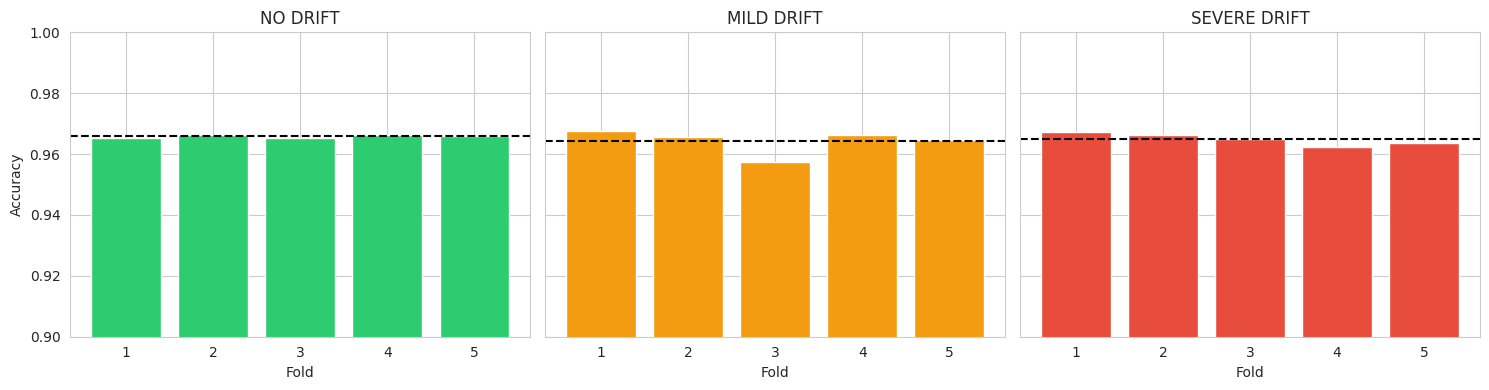

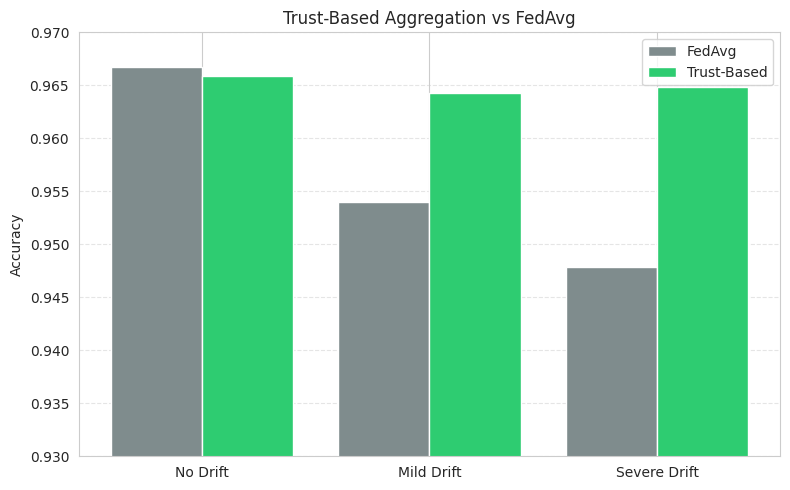

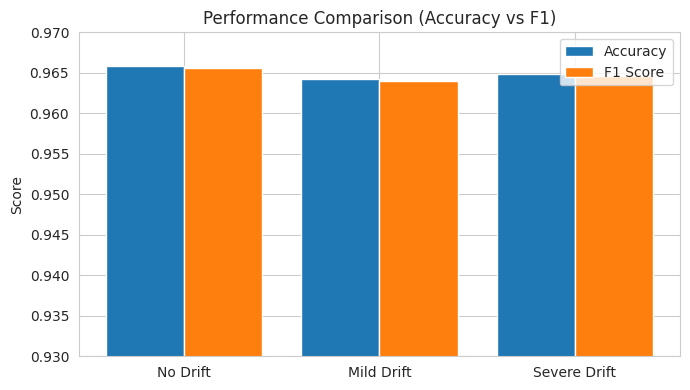

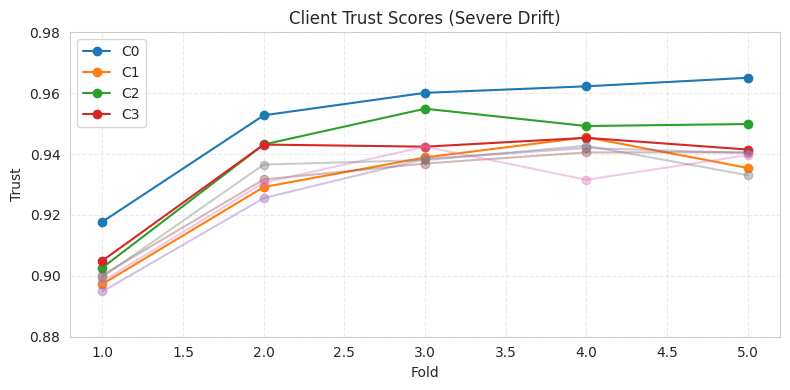

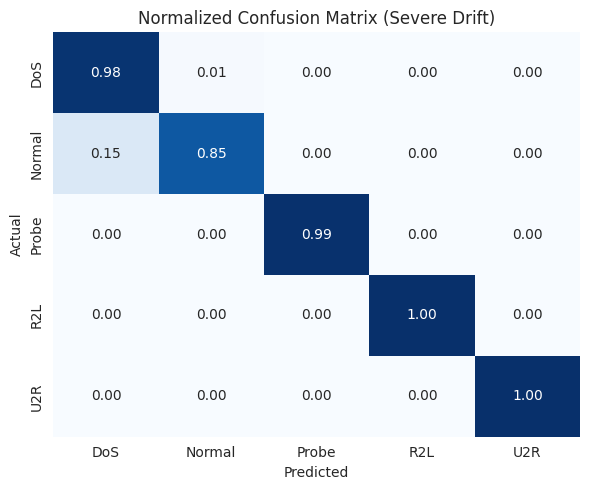

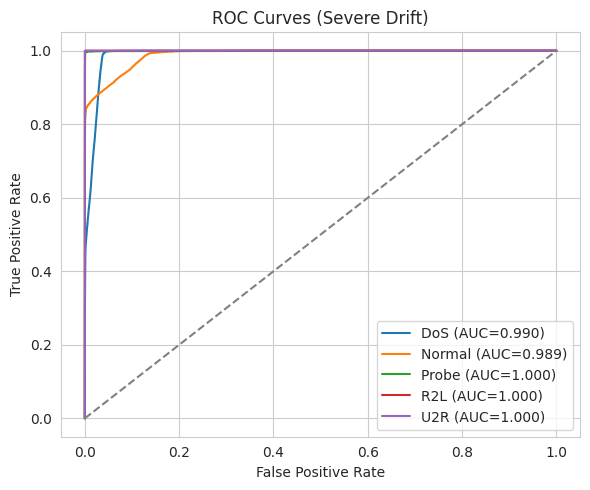

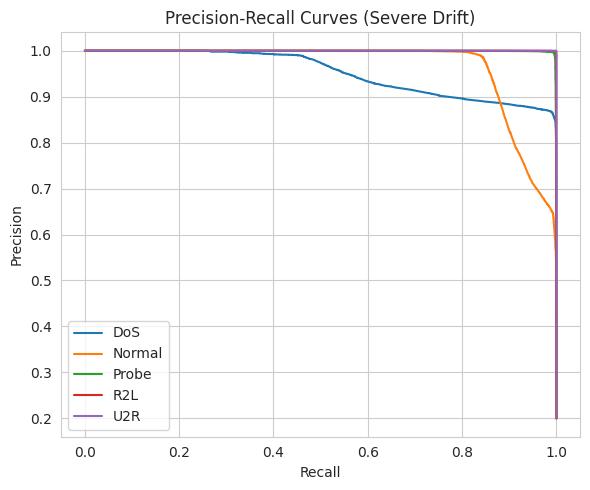

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

sns.set_style("whitegrid")

SCENARIOS = ["NO DRIFT","MILD DRIFT","SEVERE DRIFT"]
COLORS = {"NO DRIFT":"#2ecc71","MILD DRIFT":"#f39c12","SEVERE DRIFT":"#e74c3c"}

# ======================================================
# 1. ACCURACY PER FOLD
# ======================================================
fig, axes = plt.subplots(1, 3, figsize=(15,4), sharey=True)

for ax, s in zip(axes, SCENARIOS):
    accs = RESULTS[s]["accs"]
    mean_acc = RESULTS[s]["mean_acc"]
    folds = range(1, len(accs)+1)

    ax.bar(folds, accs, color=COLORS[s])
    ax.axhline(mean_acc, linestyle="--", color="black")

    ax.set_title(s)
    ax.set_ylim(0.90,1.0)
    ax.set_xlabel("Fold")

axes[0].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

# ======================================================
# 2. TRUST vs FEDAVG
# ======================================================
trust_means = [RESULTS[s]["mean_acc"] for s in SCENARIOS]
fedavg_means = [RESULTS[s]["fedavg_mean_acc"] for s in SCENARIOS]

x = np.arange(len(SCENARIOS))

plt.figure(figsize=(8,5))

plt.bar(x - 0.2, fedavg_means, width=0.4, label="FedAvg", color="#7f8c8d")
plt.bar(x + 0.2, trust_means, width=0.4, label="Trust-Based", color="#2ecc71")

plt.xticks(x, ["No Drift","Mild Drift","Severe Drift"])
plt.ylabel("Accuracy")
plt.ylim(0.93,0.97)
plt.title("Trust-Based Aggregation vs FedAvg")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# ======================================================
# 3. ABLATION (ACC + F1)
# ======================================================
mean_accs = [RESULTS[s]["mean_acc"] for s in SCENARIOS]
mean_f1s  = [RESULTS[s]["mean_f1"] for s in SCENARIOS]

plt.figure(figsize=(7,4))
plt.bar(x-0.2, mean_accs, width=0.4, label="Accuracy")
plt.bar(x+0.2, mean_f1s,  width=0.4, label="F1 Score")

plt.xticks(x, ["No Drift","Mild Drift","Severe Drift"])
plt.ylabel("Score")
plt.ylim(0.93,0.97)
plt.legend()
plt.title("Performance Comparison (Accuracy vs F1)")

plt.tight_layout()
plt.show()

# ======================================================
# 4. TRUST CURVES (SEVERE DRIFT)
# ======================================================
trust_logs = RESULTS["SEVERE DRIFT"]["trust"]
num_clients = len(trust_logs[0])
folds = range(1, len(trust_logs)+1)

plt.figure(figsize=(8,4))

for cid in range(num_clients):
    vals = [t[cid] for t in trust_logs]

    # avoid legend clutter
    if cid < 4:
        plt.plot(folds, vals, marker="o", label=f"C{cid}")
    else:
        plt.plot(folds, vals, marker="o", alpha=0.4)

plt.title("Client Trust Scores (Severe Drift)")
plt.xlabel("Fold")
plt.ylabel("Trust")
plt.ylim(0.88,0.98)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ======================================================
# 5. NORMALIZED CONFUSION MATRIX
# ======================================================
y_true = RESULTS["SEVERE DRIFT"]["y_true"]
y_pred = RESULTS["SEVERE DRIFT"]["y_pred"]

cm = confusion_matrix(y_true, y_pred).astype(float)
cm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt=".2f",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            cmap="Blues",
            cbar=False)

plt.title("Normalized Confusion Matrix (Severe Drift)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# ======================================================
# 6. ROC CURVES
# ======================================================
y_prob = RESULTS["SEVERE DRIFT"]["y_probs"]
y_bin  = label_binarize(y_true, classes=np.arange(n_classes))

plt.figure(figsize=(6,5))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:,i], y_prob[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{CLASS_NAMES[i]} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],"--", color="gray")
plt.title("ROC Curves (Severe Drift)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

# ======================================================
# 7. PRECISION-RECALL CURVES
# ======================================================
plt.figure(figsize=(6,5))

for i in range(n_classes):
    p, r, _ = precision_recall_curve(y_bin[:,i], y_prob[:,i])
    plt.plot(r, p, label=CLASS_NAMES[i])

plt.title("Precision-Recall Curves (Severe Drift)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.tight_layout()
plt.show()

### **Exploratory Data Analysis and Statistical Visualization of the Unified IDS Dataset**

Dataset shape: (100000, 131)


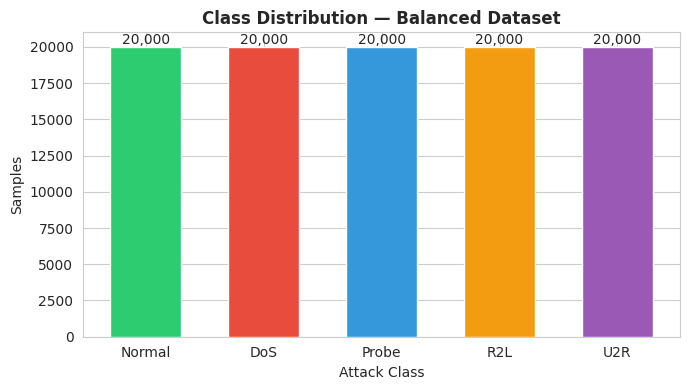

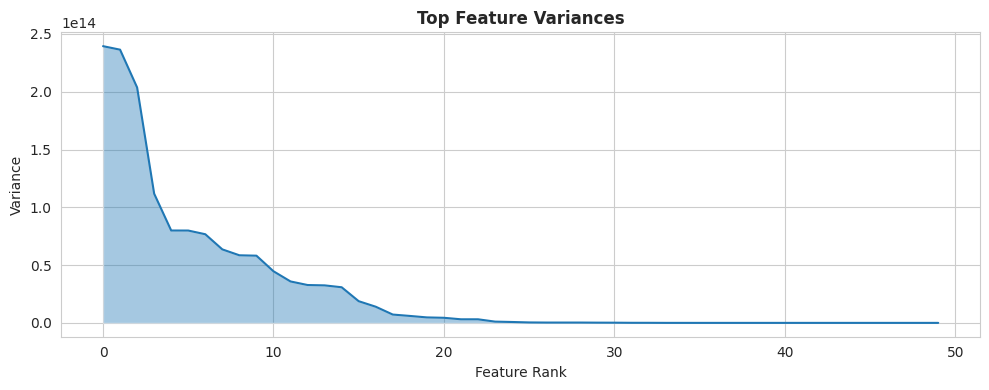

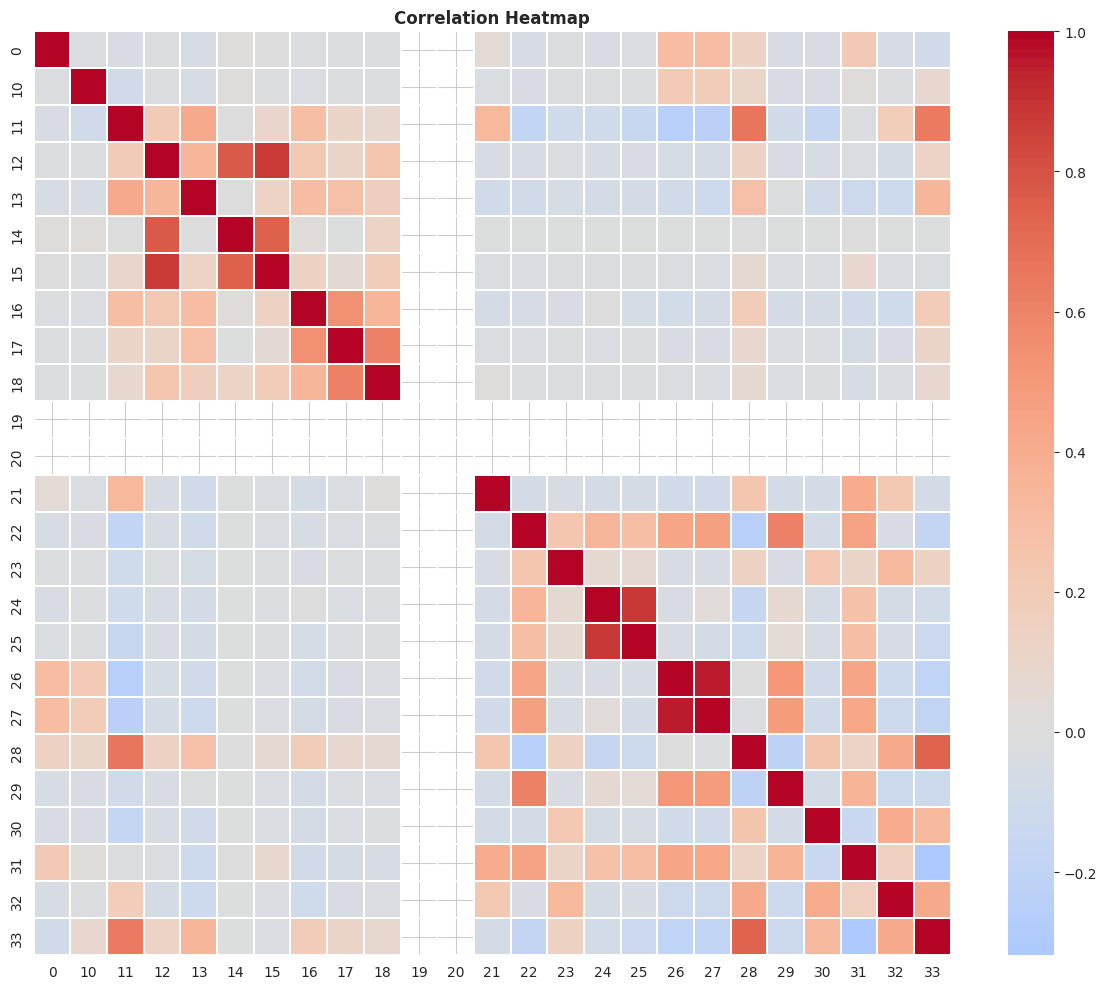

Running PCA...


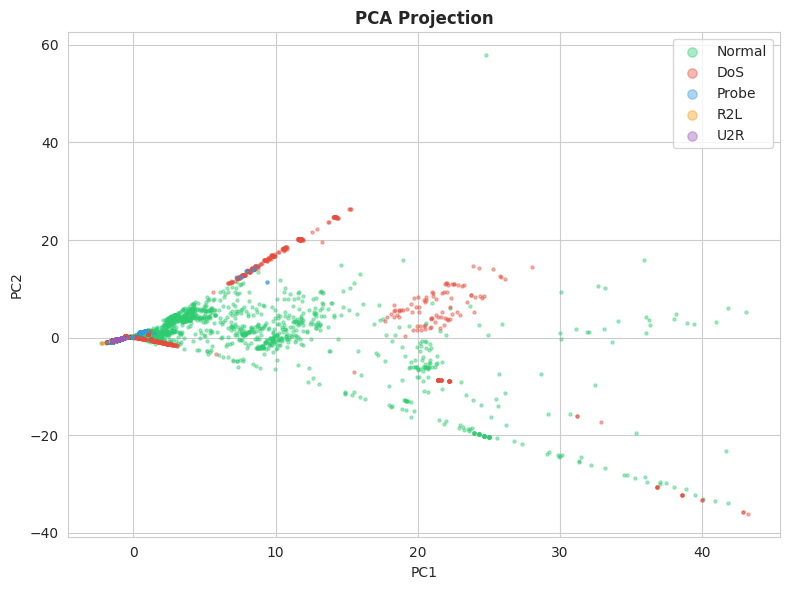


Generating cross-dataset plot...


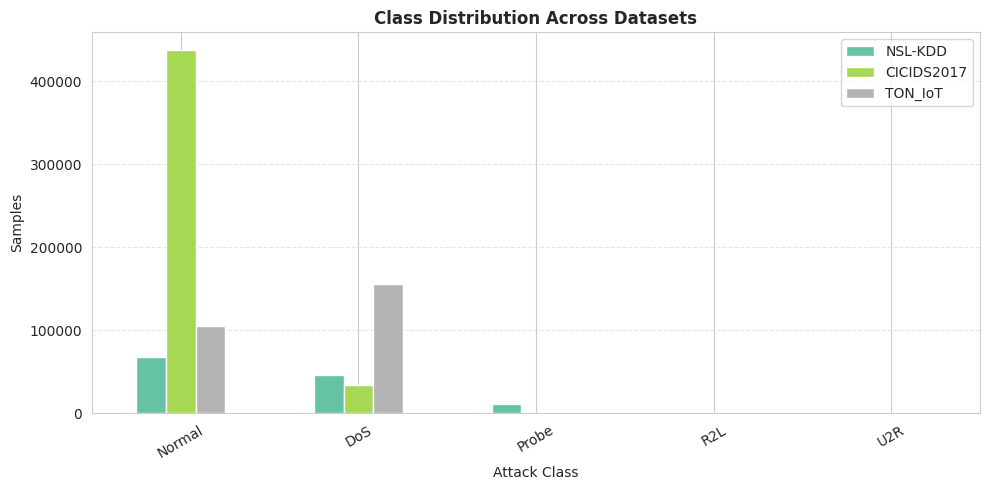


All EDA visualizations complete.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

# =========================
# LOAD
# =========================
df = pd.read_csv("Final_5Class_IDS.csv")

CLASSES = ["Normal","DoS","Probe","R2L","U2R"]

PALETTE = {
    "Normal":"#2ecc71",
    "DoS":"#e74c3c",
    "Probe":"#3498db",
    "R2L":"#f39c12",
    "U2R":"#9b59b6"
}

#  Ensure only numeric features
numeric_df = df.drop(columns=["label"]).select_dtypes(include=[np.number])

print("Dataset shape:", df.shape)

# =========================
# 1. CLASS DISTRIBUTION
# =========================
fig, ax = plt.subplots(figsize=(7, 4))

counts = df["label"].value_counts().reindex(CLASSES, fill_value=0)

bars = ax.bar(counts.index, counts.values,
              color=[PALETTE[c] for c in counts.index],
              edgecolor="white", width=0.6)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(counts.values)*0.01,
            f"{val:,}", ha="center", fontsize=10)

ax.set_title("Class Distribution — Balanced Dataset", fontweight="bold")
ax.set_xlabel("Attack Class")
ax.set_ylabel("Samples")

plt.tight_layout()
plt.savefig("fig_class_dist.png", dpi=300)
plt.show()

# =========================
# 2. FEATURE VARIANCE
# =========================
variances = numeric_df.var().sort_values(ascending=False)

top_k = min(50, len(variances))

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(range(top_k), variances.values[:top_k], alpha=0.4)
ax.plot(variances.values[:top_k], linewidth=1.5)

ax.set_title("Top Feature Variances", fontweight="bold")
ax.set_xlabel("Feature Rank")
ax.set_ylabel("Variance")

plt.tight_layout()
plt.savefig("fig_variance.png", dpi=300)
plt.show()

# =========================
# 3. CORRELATION HEATMAP
# =========================
subset = numeric_df.columns[:min(25, len(numeric_df.columns))]

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df[subset].corr(),
            cmap="coolwarm", center=0, linewidths=0.3)

plt.title("Correlation Heatmap", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_corr.png", dpi=300)
plt.show()

# =========================
# 4. PCA VISUALIZATION
# =========================
print("Running PCA...")

#  Safe sampling
sample_size = min(20000, len(df))
sample = df.sample(sample_size, random_state=42)

X_sample = sample.drop(columns=["label"]).select_dtypes(include=[np.number])
y_sample = sample["label"]

#  Handle NaN / inf
X_sample = X_sample.replace([np.inf, -np.inf], 0).fillna(0)

X_scaled = StandardScaler().fit_transform(X_sample)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    "PC1": pca_result[:,0],
    "PC2": pca_result[:,1],
    "label": y_sample.values
})

plt.figure(figsize=(8,6))

for cls in CLASSES:
    sub = df_pca[df_pca["label"] == cls]
    if len(sub) > 0:
        plt.scatter(sub["PC1"], sub["PC2"],
                    s=5, alpha=0.4,
                    color=PALETTE[cls],
                    label=cls)

plt.title("PCA Projection", fontweight="bold")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(markerscale=3)

plt.tight_layout()
plt.savefig("fig_pca.png", dpi=300)
plt.show()

# =========================
# 5. CROSS-DATASET
# =========================
print("\nGenerating cross-dataset plot...")

def safe_counts(df):
    if df is None:
        return pd.Series([0]*len(CLASSES), index=CLASSES)
    return df["label"].value_counts().reindex(CLASSES, fill_value=0)

try:
    counts_dict = {
        "NSL-KDD": safe_counts(globals().get("clean_nsl")),
        "CICIDS2017": safe_counts(globals().get("clean_cic")),
        "TON_IoT": safe_counts(globals().get("clean_ton"))
    }

    df_plot = pd.DataFrame(counts_dict)

    df_plot.plot(kind="bar", figsize=(10,5), colormap="Set2")

    plt.title("Class Distribution Across Datasets", fontweight="bold")
    plt.xlabel("Attack Class")
    plt.ylabel("Samples")
    plt.xticks(rotation=30)
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig("fig_cross_dist.png", dpi=300)
    plt.show()

except Exception as e:
    print("Skipped cross-dataset plot:", e)

print("\nAll EDA visualizations complete.")

### **Analysis of Trust-Based Aggregation Across Clients**

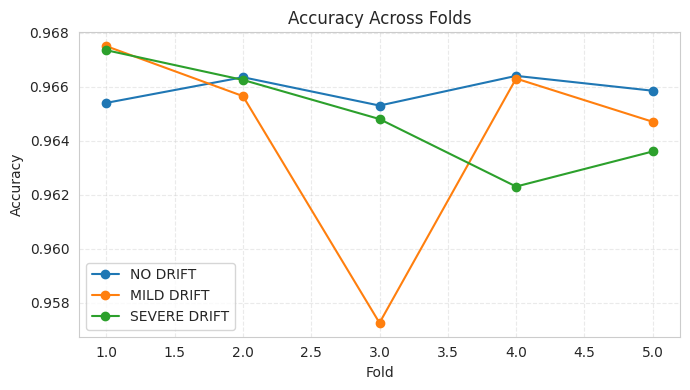

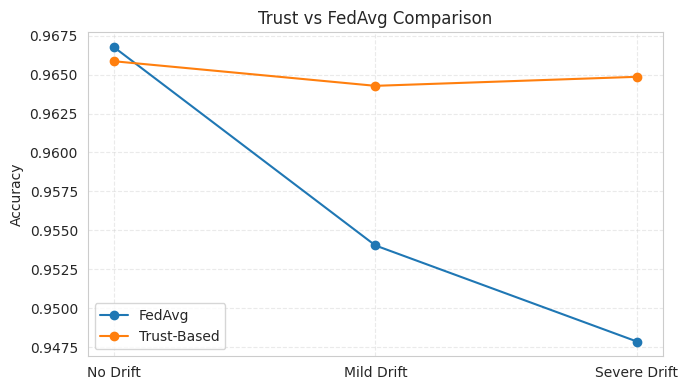

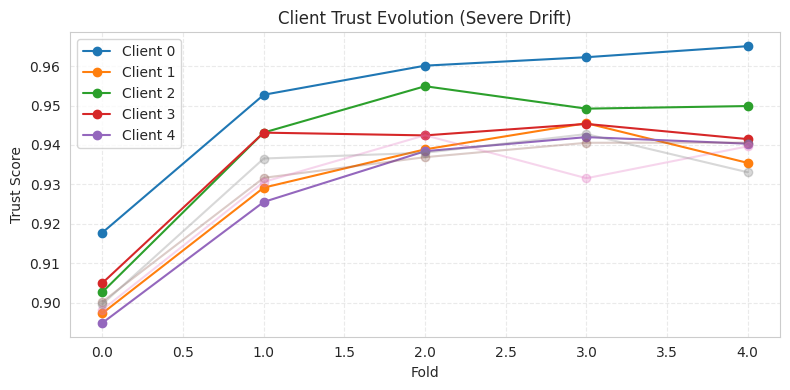


Running scalability analysis...
Testing 3 clients...

===== 3_CLIENTS =====
Client 0 Trust: 0.9196
Client 1 Trust: 0.9014
Client 2 Trust: 0.9085
Fold 1 → Trust=0.9687 | FedAvg=0.9630
Client 0 Trust: 0.9605
Client 1 Trust: 0.9391
Client 2 Trust: 0.9472
Fold 2 → Trust=0.9692 | FedAvg=0.9625
Client 0 Trust: 0.9670
Client 1 Trust: 0.9415
Client 2 Trust: 0.9531
Fold 3 → Trust=0.9663 | FedAvg=0.9600
Client 0 Trust: 0.9652
Client 1 Trust: 0.9433
Client 2 Trust: 0.9532
Fold 4 → Trust=0.9679 | FedAvg=0.9620
Client 0 Trust: 0.9693
Client 1 Trust: 0.9425
Client 2 Trust: 0.9538
Fold 5 → Trust=0.9669 | FedAvg=0.9616

FINAL:
Trust Mean: 0.9678
FedAvg Mean: 0.9618
Testing 5 clients...

===== 5_CLIENTS =====
Client 0 Trust: 0.9145
Client 1 Trust: 0.8980
Client 2 Trust: 0.9048
Client 3 Trust: 0.8974
Client 4 Trust: 0.9017
Fold 1 → Trust=0.9673 | FedAvg=0.9574
Client 0 Trust: 0.9564
Client 1 Trust: 0.9377
Client 2 Trust: 0.9452
Client 3 Trust: 0.9401
Client 4 Trust: 0.9413
Fold 2 → Trust=0.9678 | FedAv

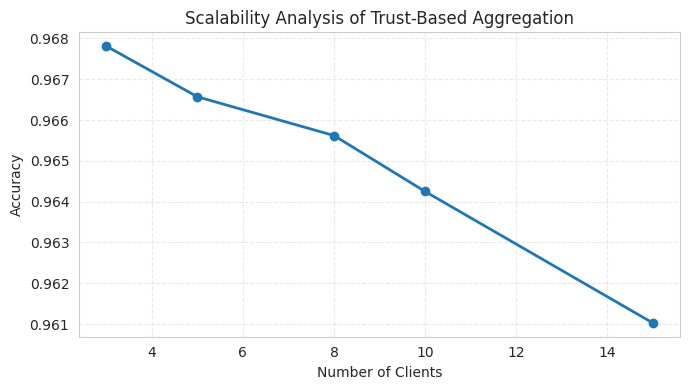

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

SCENARIOS = ["NO DRIFT","MILD DRIFT","SEVERE DRIFT"]

# =======================
# 1. ACCURACY PER FOLD
# =======================
plt.figure(figsize=(7,4))

for s in SCENARIOS:
    accs = RESULTS[s]["accs"]
    plt.plot(range(1, len(accs)+1), accs, marker='o', label=s)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Accuracy Across Folds")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ====================
# 2. TRUST vs FEDAVG
# ====================
trust_means = [RESULTS[s]["mean_acc"] for s in SCENARIOS]
fedavg_means = [RESULTS[s]["fedavg_mean_acc"] for s in SCENARIOS]

x = np.arange(len(SCENARIOS))

plt.figure(figsize=(7,4))

plt.plot(x, fedavg_means, marker='o', label="FedAvg")
plt.plot(x, trust_means, marker='o', label="Trust-Based")

plt.xticks(x, ["No Drift","Mild Drift","Severe Drift"])
plt.ylabel("Accuracy")
plt.title("Trust vs FedAvg Comparison")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ======================================================
# 3. TRUST CURVES
# ======================================================
trust_logs = RESULTS["SEVERE DRIFT"]["trust"]
num_clients = len(trust_logs[0])

plt.figure(figsize=(8,4))

for cid in range(num_clients):
    vals = [t[cid] for t in trust_logs]

    if cid < 5:
        plt.plot(vals, marker='o', label=f"Client {cid}")
    else:
        plt.plot(vals, marker='o', alpha=0.3)

plt.xlabel("Fold")
plt.ylabel("Trust Score")
plt.title("Client Trust Evolution (Severe Drift)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ======================================================
# 4. SCALABILITY ANALYSIS
# ======================================================
CLIENT_SETTINGS = [3, 5, 8, 10, 15]

scalability_results = []

print("\nRunning scalability analysis...")

for n in CLIENT_SETTINGS:
    print(f"Testing {n} clients...")

    NUM_CLIENTS = n
    run_experiment(f"{n}_CLIENTS", DRIFT_CFG["SEVERE DRIFT"])

    scalability_results.append(RESULTS[f"{n}_CLIENTS"]["mean_acc"])

plt.figure(figsize=(7,4))

plt.plot(CLIENT_SETTINGS, scalability_results, marker='o', linewidth=2)

plt.xlabel("Number of Clients")
plt.ylabel("Accuracy")
plt.title("Scalability Analysis of Trust-Based Aggregation")
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [16]:
from scipy.stats import t

def confidence_interval(data, confidence=0.95):
    data = np.array(data)
    mean = np.mean(data)
    sem = np.std(data, ddof=1) / np.sqrt(len(data))
    h = sem * t.ppf((1 + confidence) / 2., len(data)-1)
    return mean - h, mean + h

print("\n95% CONFIDENCE INTERVALS:")

for s in SCENARIOS:
    trust = RESULTS[s]["accs"]
    fed   = RESULTS[s]["fedavg_accs"]

    t_low, t_high = confidence_interval(trust)
    f_low, f_high = confidence_interval(fed)

    print(f"\n{s}")
    print(f"Trust:  [{t_low:.4f}, {t_high:.4f}]")
    print(f"FedAvg: [{f_low:.4f}, {f_high:.4f}]")


95% CONFIDENCE INTERVALS:

NO DRIFT
Trust:  [0.9652, 0.9665]
FedAvg: [0.9656, 0.9680]

MILD DRIFT
Trust:  [0.9592, 0.9693]
FedAvg: [0.9520, 0.9560]

SEVERE DRIFT
Trust:  [0.9624, 0.9674]
FedAvg: [0.9454, 0.9503]


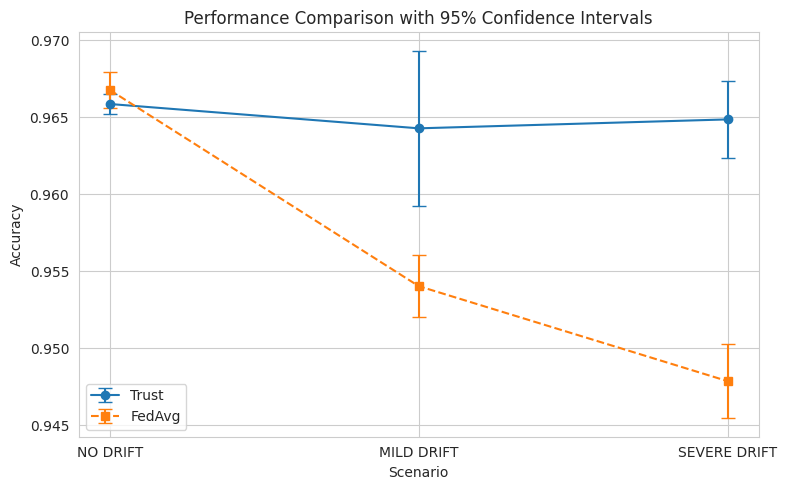

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# =========================
# FUNCTION: 95% CI
# =========================
def mean_ci(data, confidence=0.95):
    data = np.array(data)
    mean = np.mean(data)
    sem = np.std(data, ddof=1) / np.sqrt(len(data))
    h = sem * t.ppf((1 + confidence) / 2., len(data)-1)
    return mean, h

# =========================
# EXTRACT FROM YOUR RESULTS
# =========================
SCENARIOS = ["NO DRIFT", "MILD DRIFT", "SEVERE DRIFT"]

trust_means, trust_ci = [], []
fed_means, fed_ci = [], []

for s in SCENARIOS:
    m, h = mean_ci(RESULTS[s]["accs"])
    trust_means.append(m)
    trust_ci.append(h)

    m, h = mean_ci(RESULTS[s]["fedavg_accs"])
    fed_means.append(m)
    fed_ci.append(h)

# =========================
# PLOT
# =========================
x = np.arange(len(SCENARIOS))

plt.figure(figsize=(8,5))

plt.errorbar(x, trust_means, yerr=trust_ci, fmt='o-', capsize=5, label='Trust')
plt.errorbar(x, fed_means, yerr=fed_ci, fmt='s--', capsize=5, label='FedAvg')

plt.xticks(x, SCENARIOS)
plt.xlabel("Scenario")
plt.ylabel("Accuracy")
plt.title("Performance Comparison with 95% Confidence Intervals")

plt.legend()
plt.grid(True)

plt.tight_layout()

# =========================
# SAVE FIGURE
# =========================
plt.savefig("figure_accuracy_ci.png", dpi=300)

plt.show()

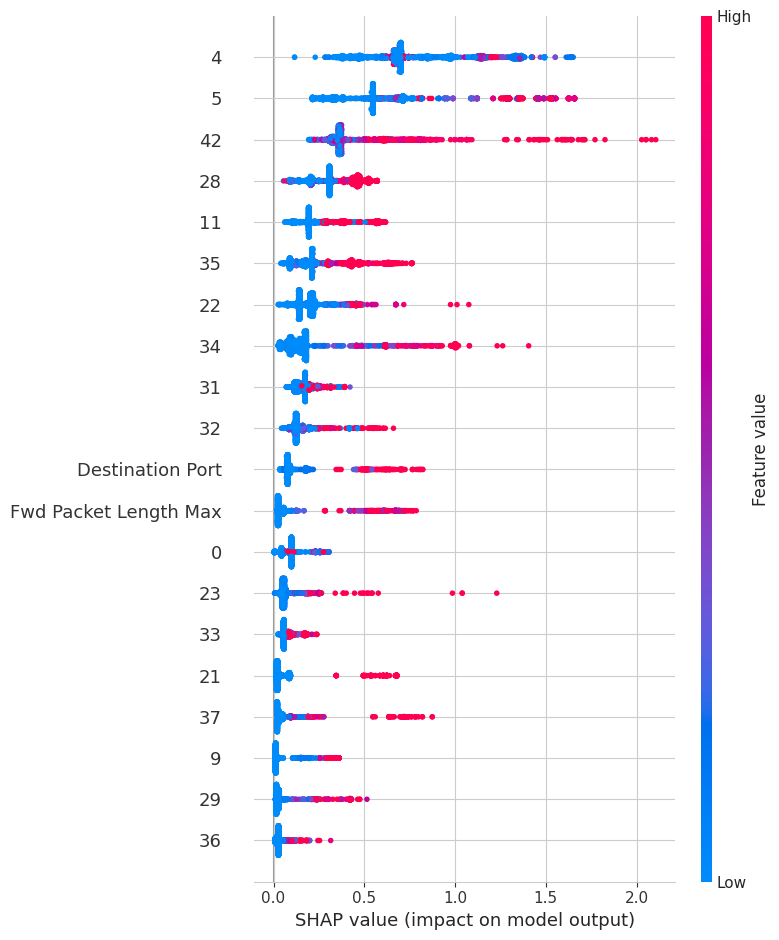

<Figure size 640x480 with 0 Axes>

In [18]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# feature names
try:
    feature_names = X_raw.columns
except:
    try:
        feature_names = df.drop(columns=["label"]).columns
    except:
        feature_names = [f"f{i}" for i in range(X_sc.shape[1])]

# train model
model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y_enc)),
    n_estimators=120,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    verbosity=0,
    random_state=42
)

model.fit(X_sc, y_enc)

# sample
X_sample = X_sc[:2000] if len(X_sc) > 2000 else X_sc

explainer = shap.TreeExplainer(model, feature_perturbation="interventional")

shap_values = explainer(X_sample)


if isinstance(shap_values.values, np.ndarray) and shap_values.values.ndim == 3:
    shap_vals = np.mean(np.abs(shap_values.values), axis=2)
else:
    shap_vals = shap_values.values

shap.summary_plot(
    shap_vals,
    X_sample,
    feature_names=feature_names
)

plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")

In [19]:
import hashlib
import time
import json

audit_log = []

def compute_hash(index, timestamp, data, prev_hash):
    block_string = f"{index}{timestamp}{json.dumps(data, sort_keys=True)}{prev_hash}"
    return hashlib.sha256(block_string.encode()).hexdigest()

prev_hash = "0"

for k, scenario in enumerate(["NO DRIFT", "MILD DRIFT", "SEVERE DRIFT"]):

    data = {
        "trust_scores": RESULTS[scenario]["accs"],
        "metrics": {
            "accuracy": RESULTS[scenario]["mean_acc"],
            "f1": RESULTS[scenario]["mean_f1"]
        }
    }

    timestamp = time.time()

    current_hash = compute_hash(k, timestamp, data, prev_hash)

    block = {
        "index": k,
        "timestamp": timestamp,
        "data": data,
        "prev_hash": prev_hash,
        "hash": current_hash
    }

    audit_log.append(block)
    prev_hash = current_hash

# print audit chain
for block in audit_log:
    print(f"Block {block['index']} | Hash: {block['hash'][:10]} | Prev: {block['prev_hash'][:10]}")

Block 0 | Hash: c984bdacf4 | Prev: 0
Block 1 | Hash: 8242d1a157 | Prev: c984bdacf4
Block 2 | Hash: 82506175e0 | Prev: 8242d1a157


### **Experiments**

In [20]:
import os
import time
import json
import math
import random
import hashlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from IPython.display import display

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import t
from scipy.spatial.distance import pdist, squareform

import xgboost as xgb

warnings.filterwarnings("ignore")

# -----------------------------
# 0) GLOBAL CONFIG
# -----------------------------
exp_config = {
    "random_state": 42,
    "base_clients": 8,
    "cv_folds": 5,
    "scalability_folds": 3,
    "independent_runs": 5,
    "reference_samples": 512,
    "poison_rates": [0.0, 0.1, 0.2, 0.3 , 0.4 , 0.5 , 0.6],
    "scalability_clients": [3, 5, 10, 20, 30, 50],
    "robust_scenarios": ["NO DRIFT", "MILD DRIFT", "SEVERE DRIFT"],
    "trust_ablation_modes": {
        "Accuracy Only": (1.0, 0.0, 0.0),
        "Accuracy + Confidence": (0.8, 0.2, 0.0),
        "Accuracy + Confidence + Historical Trust": (0.7, 0.2, 0.1),
    },
    "drift_cfg": {
        "NO DRIFT":     dict(noise=0.00, blackout=0.00, flip=0.00),
        "MILD DRIFT":   dict(noise=0.04, blackout=0.08, flip=0.02),
        "SEVERE DRIFT": dict(noise=0.08, blackout=0.12, flip=0.04),
    }
}

def exp_seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

exp_seed_everything(exp_config["random_state"])

# -----------------------------
# 1) FALLBACK DATA LOADING
# -----------------------------
def exp_prepare_data():

    global X_sc, y_enc, CLASS_NAMES, n_classes, X_raw, y_raw, scaler, le, df

    if all(v in globals() for v in ["X_sc", "y_enc", "CLASS_NAMES", "n_classes"]):
        print("[OK] Using existing in-memory data variables.")
        return

    print("[INFO] Rebuilding data from Final_5Class_IDS.csv ...")
    df = pd.read_csv("Final_5Class_IDS.csv")

    X_raw = df.drop(columns=["label"])
    y_raw = df["label"]

    X_raw = X_raw.loc[:, X_raw.nunique() > 1]
    X_raw = X_raw.replace([np.inf, -np.inf], 0).fillna(0).clip(-1e6, 1e6)

    le = LabelEncoder()
    y_enc = le.fit_transform(y_raw)
    CLASS_NAMES = list(le.classes_)
    n_classes = len(CLASS_NAMES)

    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X_raw)

    print(f"[OK] Data ready. X_sc={X_sc.shape}, classes={CLASS_NAMES}")

exp_prepare_data()


# -----------------------------
# 2) UTILITY FUNCTIONS
# -----------------------------
def exp_safe_train_test_split(X, y, test_size=0.2, seed=42):

    try:
        return train_test_split(
            X, y,
            test_size=test_size,
            stratify=y,
            random_state=seed
        )
    except Exception:
        return train_test_split(
            X, y,
            test_size=test_size,
            shuffle=True,
            random_state=seed
        )

def exp_ensure_all_classes(X_loc, y_loc, num_classes):

    y_loc = np.asarray(y_loc)
    X_loc = np.asarray(X_loc)

    missing = [c for c in range(num_classes) if c not in y_loc]
    if not missing:
        return X_loc, y_loc

    for c in missing:
        X_loc = np.vstack([X_loc, np.zeros((1, X_loc.shape[1]))])
        y_loc = np.append(y_loc, c)

    return X_loc, y_loc

def exp_poison_labels(y, ratio=0.3, seed=42):

    y = np.asarray(y).copy()
    n = int(len(y) * ratio)
    if n <= 0:
        return y
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(y), n, replace=False)
    y[idx] = rng.permutation(y[idx])
    return y

def exp_apply_degradation(X, y, cid, cfg, seed=42):

    rng = np.random.default_rng(seed + cid)
    X = np.asarray(X).copy()
    y = np.asarray(y).copy()

    if cfg.get("noise", 0) > 0:
        X += rng.normal(0, cfg["noise"] * (1 + 0.3 * cid), X.shape)

    if cfg.get("blackout", 0) > 0:
        k = int(X.shape[1] * cfg["blackout"])
        if k > 0:
            X[:, :k] = 0

    if cid == 1 and cfg.get("flip", 0) > 0:
        y = exp_poison_labels(y, cfg["flip"], seed=seed + 99)

    return X, y

def exp_compute_trust(model, X_val, y_val, prev_trust, alpha=0.7, beta=0.2, gamma=0.1):
    probs = model.predict_proba(X_val)
    pred = np.argmax(probs, axis=1)
    acc = accuracy_score(y_val, pred)
    conf = np.mean(np.max(probs, axis=1))
    trust = alpha * acc + beta * conf + gamma * prev_trust
    return float(trust), float(acc), float(conf)

def exp_build_model(cid=0, light=False, seed=42):

    if light:
        if cid == 0:
            return xgb.XGBClassifier(
                objective="multi:softprob",
                num_class=n_classes,
                n_estimators=80,
                max_depth=5,
                learning_rate=0.07,
                subsample=0.9,
                colsample_bytree=0.9,
                tree_method="hist",
                verbosity=0,
                random_state=seed
            )
        return xgb.XGBClassifier(
            objective="multi:softprob",
            num_class=n_classes,
            n_estimators=60,
            max_depth=4,
            learning_rate=0.08,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method="hist",
            verbosity=0,
            random_state=seed
        )

    if cid == 0:
        return xgb.XGBClassifier(
            objective="multi:softprob",
            num_class=n_classes,
            n_estimators=150,
            max_depth=7,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            tree_method="hist",
            verbosity=0,
            random_state=seed
        )

    return xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=n_classes,
        n_estimators=100,
        max_depth=5,
        learning_rate=0.08,
        subsample=0.75,
        colsample_bytree=0.75,
        tree_method="hist",
        verbosity=0,
        random_state=seed
    )

def exp_make_reference_set(Xtr, ytr, max_samples=512, seed=42):

    Xtr = np.asarray(Xtr)
    ytr = np.asarray(ytr)
    rng = np.random.default_rng(seed)

    n = min(max_samples, len(Xtr))
    if n <= 0:
        return Xtr[:0], ytr[:0]

    idx = rng.choice(len(Xtr), n, replace=False)
    return Xtr[idx], ytr[idx]

def exp_cos_sim(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)

def exp_stack_probs(prob_list):
    return np.stack(prob_list, axis=0)

# -----------------------------
# 3) AGGREGATORS
# -----------------------------
def exp_agg_fedavg(prob_list):
    return np.mean(exp_stack_probs(prob_list), axis=0)

def exp_agg_median(prob_list):
    return np.median(exp_stack_probs(prob_list), axis=0)

def exp_agg_trimmed_mean(prob_list, trim_ratio=0.2):
    stack = exp_stack_probs(prob_list)
    n = stack.shape[0]
    k = int(np.floor(n * trim_ratio))
    if 2 * k >= n:
        return np.mean(stack, axis=0)
    s = np.sort(stack, axis=0)
    return np.mean(s[k:n-k], axis=0)

def exp_krum_select(vectors, f=1):

    V = np.vstack(vectors)
    n = V.shape[0]

    if n <= 2:
        return 0, np.zeros(n)

    dists = squareform(pdist(V, metric="euclidean"))
    m = max(1, n - f - 2)

    scores = []
    for i in range(n):
        row = np.delete(dists[i], i)
        row_sorted = np.sort(row)
        scores.append(np.sum(row_sorted[:m]))

    scores = np.array(scores)
    idx = int(np.argmin(scores))
    return idx, scores

def exp_agg_krum(prob_list, f=1):
    vectors = [p.mean(axis=0).ravel() for p in prob_list]
    idx, _ = exp_krum_select(vectors, f=f)
    return prob_list[idx]

def exp_agg_multi_krum(prob_list, f=1):
    vectors = [p.mean(axis=0).ravel() for p in prob_list]
    V = np.vstack(vectors)
    n = V.shape[0]

    if n <= 2:
        return np.mean(exp_stack_probs(prob_list), axis=0)

    dists = squareform(pdist(V, metric="euclidean"))
    m = max(1, n - f - 2)

    scores = []
    for i in range(n):
        row = np.delete(dists[i], i)
        row_sorted = np.sort(row)
        scores.append(np.sum(row_sorted[:m]))

    scores = np.array(scores)
    selected = np.argsort(scores)[:m]
    return np.mean(exp_stack_probs([prob_list[i] for i in selected]), axis=0)

def exp_agg_fltrust(prob_list, ref_model, X_ref):

    ref_prob = ref_model.predict_proba(X_ref).mean(axis=0).ravel()
    client_vecs = [p.mean(axis=0).ravel() for p in prob_list]
    sims = np.array([max(0.0, exp_cos_sim(v, ref_prob)) for v in client_vecs], dtype=float)

    if sims.sum() <= 1e-12:
        w = np.ones(len(prob_list)) / len(prob_list)
    else:
        w = sims / sims.sum()

    return np.tensordot(w, exp_stack_probs(prob_list), axes=(0, 0))

def exp_agg_foolsgold(prob_list):

    vectors = [p.mean(axis=0).ravel() for p in prob_list]
    V = np.vstack(vectors)

    if len(prob_list) <= 2:
        return np.mean(exp_stack_probs(prob_list), axis=0)

    sim = cosine_similarity(V)
    np.fill_diagonal(sim, 0.0)
    max_sim = np.max(sim, axis=1)
    w = 1.0 - np.clip(max_sim, 0.0, 1.0)
    w = np.maximum(w, 0.0)

    if w.sum() <= 1e-12:
        w = np.ones(len(prob_list)) / len(prob_list)
    else:
        w = w / w.sum()

    return np.tensordot(w, exp_stack_probs(prob_list), axes=(0, 0))

def exp_agg_trust(prob_list, trust_scores):
    t_scores = np.asarray(trust_scores, dtype=float)
    t = (t_scores - t_scores.min()) / (t_scores.max() - t_scores.min() + 1e-12)
    t = t ** 8
    if t.sum() <= 1e-12:
        t = np.ones(len(prob_list)) / len(prob_list)
    else:
        t = t / t.sum()
    return np.tensordot(t, exp_stack_probs(prob_list), axes=(0, 0))

# -----------------------------
# 4) CORE TRAIN / EVAL FUNCTION
# -----------------------------
def exp_train_fold_clients(Xtr, ytr, num_clients, cfg, seed=42, light=False, trust_mode=(0.7, 0.2, 0.1)):

    rng = np.random.default_rng(seed)
    splits = np.array_split(np.arange(len(Xtr)), num_clients)

    prev_trusts = np.ones(num_clients, dtype=float) * 0.5
    models = []
    trust_scores = []

    # shared clean reference set for FLTrust/FoolsGold/Krum analogues
    X_ref, y_ref = exp_make_reference_set(Xtr, ytr, max_samples=exp_config["reference_samples"], seed=seed)
    ref_model = exp_build_model(cid=0, light=True, seed=seed)
    if len(X_ref) > 0:
        ref_model.fit(X_ref, y_ref)

    for cid, idx in enumerate(splits):
        idx = np.asarray(idx)
        if len(idx) == 0:
            continue

        frac = rng.uniform(0.7, 1.0)
        keep_n = max(2, int(len(idx) * frac))
        keep_n = min(keep_n, len(idx))
        idx = rng.choice(idx, keep_n, replace=False)

        X_loc = Xtr[idx]
        y_loc = ytr[idx]

        X_loc, y_loc = exp_ensure_all_classes(X_loc, y_loc, n_classes)

        X_tr, X_val, y_tr, y_val = exp_safe_train_test_split(
            X_loc, y_loc, test_size=0.2, seed=seed + cid
        )

        if cid > 0:
            X_tr, y_tr = exp_apply_degradation(X_tr, y_tr, cid, cfg, seed=seed + 1000)

        model = exp_build_model(cid=cid, light=light, seed=seed + cid)
        model.fit(X_tr, y_tr)

        alpha, beta, gamma = trust_mode
        trust, acc, conf = exp_compute_trust(model, X_val, y_val, prev_trusts[cid], alpha, beta, gamma)
        prev_trusts[cid] = trust

        models.append(model)
        trust_scores.append(trust)

    return {
        "models": models,
        "trust_scores": trust_scores,
        "ref_model": ref_model,
        "X_ref": X_ref,
        "y_ref": y_ref,
    }

def exp_eval_aggregations(models, trust_scores, ref_model, X_ref, Xte, yte, methods=None):

    if methods is None:
        methods = ["Trust", "FedAvg", "Krum", "Multi-Krum", "Median", "Trimmed Mean", "FLTrust", "FoolsGold"]

    prob_test = [m.predict_proba(Xte) for m in models]
    out = {}

    if "Trust" in methods:
        p = exp_agg_trust(prob_test, trust_scores)
        pred = np.argmax(p, axis=1)
        out["Trust"] = {
            "acc": accuracy_score(yte, pred),
            "macro_f1": f1_score(yte, pred, average="macro"),
            "weighted_f1": f1_score(yte, pred, average="weighted"),
            "pred": pred,
            "probs": p
        }

    if "FedAvg" in methods:
        p = exp_agg_fedavg(prob_test)
        pred = np.argmax(p, axis=1)
        out["FedAvg"] = {
            "acc": accuracy_score(yte, pred),
            "macro_f1": f1_score(yte, pred, average="macro"),
            "weighted_f1": f1_score(yte, pred, average="weighted"),
            "pred": pred,
            "probs": p
        }

    if "Krum" in methods:
        p = exp_agg_krum(prob_test, f=1)
        pred = np.argmax(p, axis=1)
        out["Krum"] = {
            "acc": accuracy_score(yte, pred),
            "macro_f1": f1_score(yte, pred, average="macro"),
            "weighted_f1": f1_score(yte, pred, average="weighted"),
            "pred": pred,
            "probs": p
        }

    if "Multi-Krum" in methods:
        p = exp_agg_multi_krum(prob_test, f=1)
        pred = np.argmax(p, axis=1)
        out["Multi-Krum"] = {
            "acc": accuracy_score(yte, pred),
            "macro_f1": f1_score(yte, pred, average="macro"),
            "weighted_f1": f1_score(yte, pred, average="weighted"),
            "pred": pred,
            "probs": p
        }

    if "Median" in methods:
        p = exp_agg_median(prob_test)
        pred = np.argmax(p, axis=1)
        out["Median"] = {
            "acc": accuracy_score(yte, pred),
            "macro_f1": f1_score(yte, pred, average="macro"),
            "weighted_f1": f1_score(yte, pred, average="weighted"),
            "pred": pred,
            "probs": p
        }

    if "Trimmed Mean" in methods:
        p = exp_agg_trimmed_mean(prob_test, trim_ratio=0.2)
        pred = np.argmax(p, axis=1)
        out["Trimmed Mean"] = {
            "acc": accuracy_score(yte, pred),
            "macro_f1": f1_score(yte, pred, average="macro"),
            "weighted_f1": f1_score(yte, pred, average="weighted"),
            "pred": pred,
            "probs": p
        }

    if "FLTrust" in methods:
        if ref_model is None or len(X_ref) == 0:
            p = exp_agg_fedavg(prob_test)
        else:
            p = exp_agg_fltrust(prob_test, ref_model, X_ref)
        pred = np.argmax(p, axis=1)
        out["FLTrust"] = {
            "acc": accuracy_score(yte, pred),
            "macro_f1": f1_score(yte, pred, average="macro"),
            "weighted_f1": f1_score(yte, pred, average="weighted"),
            "pred": pred,
            "probs": p
        }

    if "FoolsGold" in methods:
        p = exp_agg_foolsgold(prob_test)
        pred = np.argmax(p, axis=1)
        out["FoolsGold"] = {
            "acc": accuracy_score(yte, pred),
            "macro_f1": f1_score(yte, pred, average="macro"),
            "weighted_f1": f1_score(yte, pred, average="weighted"),
            "pred": pred,
            "probs": p
        }

    return out

def exp_run_cv_experiment(cfg, num_clients=8, folds=5, seed=42, light=False, trust_mode=(0.7, 0.2, 0.1),
                          methods=None, scenario_name="SCENARIO"):

    if methods is None:
        methods = ["Trust", "FedAvg"]

    skf_local = StratifiedKFold(n_splits=folds, shuffle=True, random_state=seed)
    results = {m: {"accs": [], "macro_f1s": [], "weighted_f1s": []} for m in methods}

    all_true = []
    all_pred_trust = []
    all_prob_trust = []
    trust_logs = []

    for fold, (tr, te) in enumerate(skf_local.split(X_sc, y_enc), 1):
        Xtr, Xte = X_sc[tr], X_sc[te]
        ytr, yte = y_enc[tr], y_enc[te]

        fold_pack = exp_train_fold_clients(
            Xtr, ytr, num_clients=num_clients, cfg=cfg, seed=seed + fold,
            light=light, trust_mode=trust_mode
        )

        out = exp_eval_aggregations(
            fold_pack["models"],
            fold_pack["trust_scores"],
            fold_pack["ref_model"],
            fold_pack["X_ref"],
            Xte, yte,
            methods=methods
        )

        trust_logs.append(fold_pack["trust_scores"])

        for m in out:
            results[m]["accs"].append(out[m]["acc"])
            results[m]["macro_f1s"].append(out[m]["macro_f1"])
            results[m]["weighted_f1s"].append(out[m]["weighted_f1"])

        if "Trust" in out:
            all_true.extend(yte.tolist())
            all_pred_trust.extend(out["Trust"]["pred"].tolist())
            all_prob_trust.extend(out["Trust"]["probs"])

        print(f"[{scenario_name}] Fold {fold}/{folds} done.")

    summary = {}
    for m in results:
        summary[m] = {
            "mean_acc": float(np.mean(results[m]["accs"])),
            "std_acc": float(np.std(results[m]["accs"], ddof=1)) if len(results[m]["accs"]) > 1 else 0.0,
            "mean_macro_f1": float(np.mean(results[m]["macro_f1s"])),
            "mean_weighted_f1": float(np.mean(results[m]["weighted_f1s"])),
            "fold_accs": results[m]["accs"],
            "fold_macro_f1s": results[m]["macro_f1s"],
            "fold_weighted_f1s": results[m]["weighted_f1s"],
        }

    summary["trust_logs"] = trust_logs
    summary["y_true"] = np.array(all_true, dtype=int) if len(all_true) else np.array([])
    summary["y_pred_trust"] = np.array(all_pred_trust, dtype=int) if len(all_pred_trust) else np.array([])
    summary["y_prob_trust"] = np.array(all_prob_trust) if len(all_prob_trust) else np.array([])
    return summary


[OK] Using existing in-memory data variables.



EXPERIMENT 1: Robust FL baseline comparison
[NO DRIFT] Fold 1/5 done.
[NO DRIFT] Fold 2/5 done.
[NO DRIFT] Fold 3/5 done.
[NO DRIFT] Fold 4/5 done.
[NO DRIFT] Fold 5/5 done.
[MILD DRIFT] Fold 1/5 done.
[MILD DRIFT] Fold 2/5 done.
[MILD DRIFT] Fold 3/5 done.
[MILD DRIFT] Fold 4/5 done.
[MILD DRIFT] Fold 5/5 done.
[SEVERE DRIFT] Fold 1/5 done.
[SEVERE DRIFT] Fold 2/5 done.
[SEVERE DRIFT] Fold 3/5 done.
[SEVERE DRIFT] Fold 4/5 done.
[SEVERE DRIFT] Fold 5/5 done.


,Scenario,Method,Accuracy,Macro F1,Weighted F1
0,NO DRIFT,Trust,0.96385,0.963578,0.963578
1,NO DRIFT,FedAvg,0.96034,0.959978,0.959978
2,NO DRIFT,Krum,0.95882,0.958420,0.958420
3,NO DRIFT,Multi-Krum,0.96009,0.959718,0.959718
4,NO DRIFT,Median,0.96039,0.960018,0.960018
5,NO DRIFT,Trimmed Mean,0.96038,0.960012,0.960012
6,NO DRIFT,FLTrust,0.96034,0.959978,0.959978
7,NO DRIFT,FoolsGold,0.96028,0.959912,0.959912
8,MILD DRIFT,Trust,0.96470,0.964455,0.964455
9,MILD DRIFT,FedAvg,0.95015,0.949640,0.949640


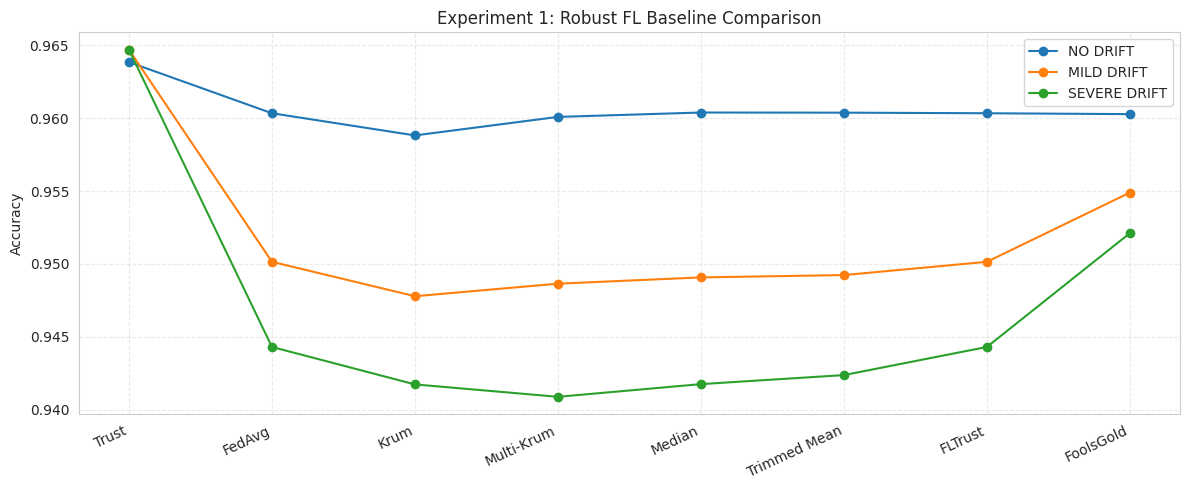

In [22]:
# ============================================================
# EXPERIMENT 1: ROBUST FL BASELINE COMPARISON
# ============================================================
print("\n" + "="*80)
print("EXPERIMENT 1: Robust FL baseline comparison")
print("="*80)

robust_results = {}
ROBUST_METHODS = ["Trust", "FedAvg", "Krum", "Multi-Krum", "Median", "Trimmed Mean", "FLTrust", "FoolsGold"]

for scenario in exp_config["robust_scenarios"]:
    cfg = exp_config["drift_cfg"][scenario]
    robust_results[scenario] = exp_run_cv_experiment(
        cfg=cfg,
        num_clients=exp_config["base_clients"],
        folds=exp_config["cv_folds"],
        seed=exp_config["random_state"],
        light=True,
        trust_mode=exp_config["trust_ablation_modes"]["Accuracy + Confidence + Historical Trust"],
        methods=ROBUST_METHODS,
        scenario_name=scenario
    )

robust_table_rows = []
for scenario in exp_config["robust_scenarios"]:
    for m in ROBUST_METHODS:
        robust_table_rows.append({
            "Scenario": scenario,
            "Method": m,
            "Accuracy": robust_results[scenario][m]["mean_acc"],
            "Macro F1": robust_results[scenario][m]["mean_macro_f1"],
            "Weighted F1": robust_results[scenario][m]["mean_weighted_f1"]
        })

robust_df = pd.DataFrame(robust_table_rows)
display(robust_df)

robust_df.to_csv("exp1_robust_baselines.csv", index=False)

# Plot: Accuracy comparison
plt.figure(figsize=(12, 5))
for scenario in exp_config["robust_scenarios"]:
    sub = robust_df[robust_df["Scenario"] == scenario]
    plt.plot(sub["Method"], sub["Accuracy"], marker="o", label=scenario)
plt.xticks(rotation=25, ha="right")
plt.ylabel("Accuracy")
plt.title("Experiment 1: Robust FL Baseline Comparison")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig("exp1_robust_baselines.png", dpi=300)
plt.show()


EXPERIMENT 2: Poisoning attack evaluation
[POISON_0] Fold 1/5 done.
[POISON_0] Fold 2/5 done.
[POISON_0] Fold 3/5 done.
[POISON_0] Fold 4/5 done.
[POISON_0] Fold 5/5 done.
[POISON_10] Fold 1/5 done.
[POISON_10] Fold 2/5 done.
[POISON_10] Fold 3/5 done.
[POISON_10] Fold 4/5 done.
[POISON_10] Fold 5/5 done.
[POISON_20] Fold 1/5 done.
[POISON_20] Fold 2/5 done.
[POISON_20] Fold 3/5 done.
[POISON_20] Fold 4/5 done.
[POISON_20] Fold 5/5 done.
[POISON_30] Fold 1/5 done.
[POISON_30] Fold 2/5 done.
[POISON_30] Fold 3/5 done.
[POISON_30] Fold 4/5 done.
[POISON_30] Fold 5/5 done.
[POISON_40] Fold 1/5 done.
[POISON_40] Fold 2/5 done.
[POISON_40] Fold 3/5 done.
[POISON_40] Fold 4/5 done.
[POISON_40] Fold 5/5 done.
[POISON_50] Fold 1/5 done.
[POISON_50] Fold 2/5 done.
[POISON_50] Fold 3/5 done.
[POISON_50] Fold 4/5 done.
[POISON_50] Fold 5/5 done.
[POISON_60] Fold 1/5 done.
[POISON_60] Fold 2/5 done.
[POISON_60] Fold 3/5 done.
[POISON_60] Fold 4/5 done.
[POISON_60] Fold 5/5 done.


,Poison Rate,Trust Accuracy,FedAvg Accuracy,Trust Macro F1,FedAvg Macro F1
0,0%,0.96470,0.94434,0.964455,0.943832
1,10%,0.96471,0.94419,0.964465,0.943684
2,20%,0.96470,0.94431,0.964455,0.943801
3,30%,0.96457,0.94420,0.964325,0.943693
4,40%,0.96423,0.94419,0.963979,0.943690
5,50%,0.96304,0.94437,0.962766,0.943868
6,60%,0.96206,0.94437,0.961766,0.943865


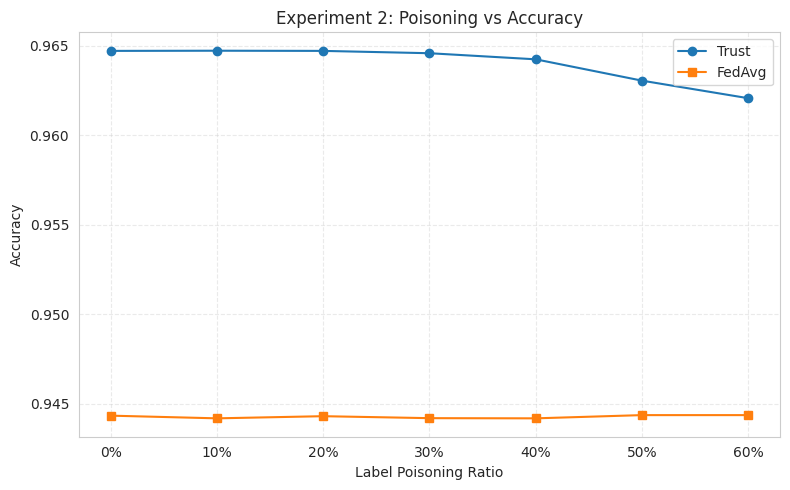

In [23]:
# ============================================================
# EXPERIMENT 2: POISONING ATTACK EVALUATION
# ============================================================
print("\n" + "="*80)
print("EXPERIMENT 2: Poisoning attack evaluation")
print("="*80)

poison_rows = []
poison_results = {}

for pr in exp_config["poison_rates"]:
    cfg = dict(exp_config["drift_cfg"]["SEVERE DRIFT"])
    cfg["flip"] = pr

    res = exp_run_cv_experiment(
        cfg=cfg,
        num_clients=exp_config["base_clients"],
        folds=exp_config["cv_folds"],
        seed=exp_config["random_state"],
        light=True,
        trust_mode=exp_config["trust_ablation_modes"]["Accuracy + Confidence + Historical Trust"],
        methods=["Trust", "FedAvg"],
        scenario_name=f"POISON_{int(pr*100)}"
    )

    poison_results[pr] = res
    poison_rows.append({
        "Poison Rate": f"{int(pr*100)}%",
        "Trust Accuracy": res["Trust"]["mean_acc"],
        "FedAvg Accuracy": res["FedAvg"]["mean_acc"],
        "Trust Macro F1": res["Trust"]["mean_macro_f1"],
        "FedAvg Macro F1": res["FedAvg"]["mean_macro_f1"]
    })

poison_df = pd.DataFrame(poison_rows)
display(poison_df)
poison_df.to_csv("exp2_poisoning_attack.csv", index=False)

plt.figure(figsize=(8, 5))
x = np.arange(len(poison_df))
plt.plot(x, poison_df["Trust Accuracy"], marker="o", label="Trust")
plt.plot(x, poison_df["FedAvg Accuracy"], marker="s", label="FedAvg")
plt.xticks(x, poison_df["Poison Rate"])
plt.xlabel("Label Poisoning Ratio")
plt.ylabel("Accuracy")
plt.title("Experiment 2: Poisoning vs Accuracy")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig("exp2_poisoning_curve.png", dpi=300)
plt.show()



EXPERIMENT 3: Communication overhead analysis


,Clients,Average Update Size (KB),Communication Cost per Round (KB),Verification Time (ms)
0,3,546.914388,1640.743164,6.140785
1,5,504.866992,2524.334961,5.844011
2,10,456.850684,4568.506836,5.188767
3,15,439.358138,6590.372070,5.292087
4,20,429.821045,8596.420898,5.046615
5,30,418.732357,12561.970703,5.764446
6,50,409.037734,20451.886719,5.227788


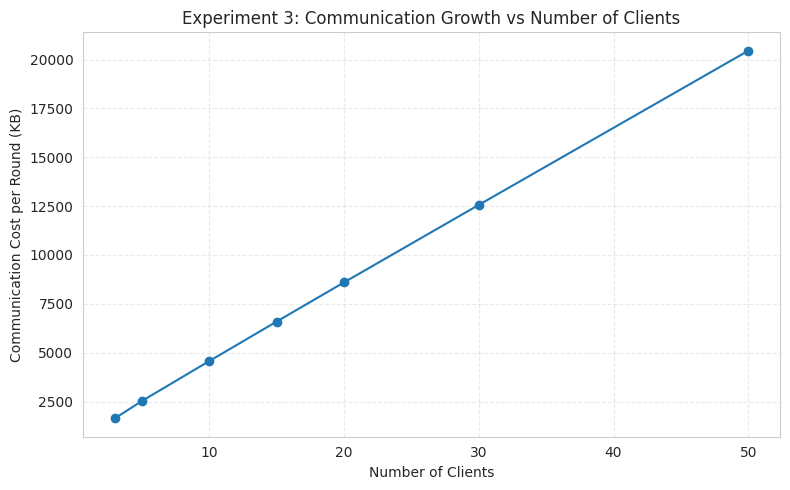

In [24]:
# ============================================================
# EXPERIMENT 3: COMMUNICATION OVERHEAD ANALYSIS
# ============================================================
print("\n" + "="*80)
print("EXPERIMENT 3: Communication overhead analysis")
print("="*80)

comm_rows = []
comm_client_counts = [3, 5, 10, 15, 20, 30, 50]

for n_clients in comm_client_counts:
    cfg = exp_config["drift_cfg"]["SEVERE DRIFT"]

    skf_local = StratifiedKFold(n_splits=3, shuffle=True, random_state=exp_config["random_state"])
    tr, te = next(skf_local.split(X_sc, y_enc))
    Xtr, ytr = X_sc[tr], y_enc[tr]

    pack = exp_train_fold_clients(
        Xtr, ytr, num_clients=n_clients, cfg=cfg,
        seed=exp_config["random_state"] + n_clients,
        light=True,
        trust_mode=exp_config["trust_ablation_modes"]["Accuracy + Confidence + Historical Trust"]
    )

    models = pack["models"]
    ref_model = pack["ref_model"]
    X_ref = pack["X_ref"]

    # average serialized model size
    model_sizes = []
    hash_times = []
    trust_times = []

    for m in models:
        raw = m.get_booster().save_raw()
        model_sizes.append(len(raw) / 1024.0)

        t0 = time.perf_counter()
        _ = hashlib.sha256(raw).hexdigest()
        t1 = time.perf_counter()
        hash_times.append((t1 - t0) * 1000.0)

        if len(X_ref) > 0:
            t2 = time.perf_counter()
            _ = m.predict_proba(X_ref).mean(axis=0)
            t3 = time.perf_counter()
            trust_times.append((t3 - t2) * 1000.0)

    avg_update_kb = float(np.mean(model_sizes))
    comm_round_kb = float(n_clients * avg_update_kb)
    verification_time_ms = float(np.mean(hash_times) + (np.mean(trust_times) if trust_times else 0.0))

    comm_rows.append({
        "Clients": n_clients,
        "Average Update Size (KB)": avg_update_kb,
        "Communication Cost per Round (KB)": comm_round_kb,
        "Verification Time (ms)": verification_time_ms
    })

comm_df = pd.DataFrame(comm_rows)
display(comm_df)
comm_df.to_csv("exp3_communication_overhead.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(comm_df["Clients"], comm_df["Communication Cost per Round (KB)"], marker="o")
plt.xlabel("Number of Clients")
plt.ylabel("Communication Cost per Round (KB)")
plt.title("Experiment 3: Communication Growth vs Number of Clients")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("exp3_comm_growth.png", dpi=300)
plt.show()



EXPERIMENT 4: Audit log storage growth


,Rounds,Log Size (KB)
0,10,3.403320
1,50,17.300781
2,100,34.669922
3,500,174.014648


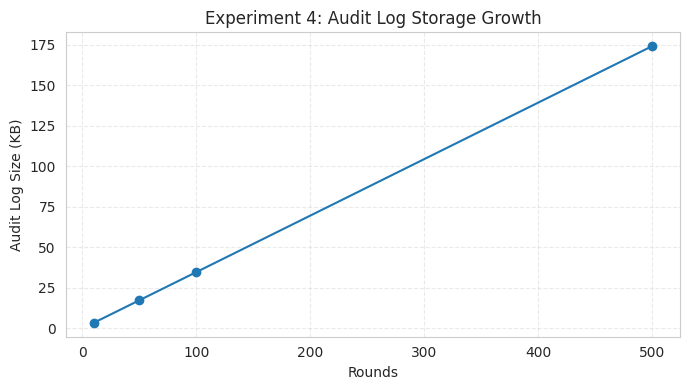

In [25]:
# ============================================================
# EXPERIMENT 4: AUDIT LOG STORAGE GROWTH
# ============================================================
print("\n" + "="*80)
print("EXPERIMENT 4: Audit log storage growth")
print("="*80)

def exp_hash_block(index, timestamp, data, prev_hash):
    block_string = f"{index}{timestamp}{json.dumps(data, sort_keys=True)}{prev_hash}"
    return hashlib.sha256(block_string.encode()).hexdigest()

def exp_build_audit_log(rounds=100, scenario_data=None):
    log = []
    prev_hash = "0"
    if scenario_data is None:
        scenario_data = {"accuracy": 0.95, "f1": 0.94}
    for k in range(rounds):
        timestamp = time.time() + k
        data = {
            "trust_scores": [float(scenario_data["accuracy"])] * 8,
            "metrics": {
                "accuracy": float(scenario_data["accuracy"]),
                "f1": float(scenario_data["f1"])
            }
        }
        h = exp_hash_block(k, timestamp, data, prev_hash)
        block = {
            "index": k,
            "timestamp": timestamp,
            "data": data,
            "prev_hash": prev_hash,
            "hash": h
        }
        log.append(block)
        prev_hash = h
    return log

audit_rounds = [10, 50, 100, 500]
audit_rows = []

base_data = {
    "accuracy": robust_results["SEVERE DRIFT"]["Trust"]["mean_acc"],
    "f1": robust_results["SEVERE DRIFT"]["Trust"]["mean_weighted_f1"]
}

for R in audit_rounds:
    log = exp_build_audit_log(rounds=R, scenario_data=base_data)
    serialized = json.dumps(log).encode("utf-8")
    size_kb = len(serialized) / 1024.0
    audit_rows.append({
        "Rounds": R,
        "Log Size (KB)": size_kb
    })

audit_df = pd.DataFrame(audit_rows)
display(audit_df)
audit_df.to_csv("exp4_audit_log_growth.csv", index=False)

plt.figure(figsize=(7, 4))
plt.plot(audit_df["Rounds"], audit_df["Log Size (KB)"], marker="o")
plt.xlabel("Rounds")
plt.ylabel("Audit Log Size (KB)")
plt.title("Experiment 4: Audit Log Storage Growth")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("exp4_audit_growth.png", dpi=300)
plt.show()



EXPERIMENT 5: Larger client scalability
[SCALE_3] Fold 1/3 done.
[SCALE_3] Fold 2/3 done.
[SCALE_3] Fold 3/3 done.
[SCALE_5] Fold 1/3 done.
[SCALE_5] Fold 2/3 done.
[SCALE_5] Fold 3/3 done.
[SCALE_10] Fold 1/3 done.
[SCALE_10] Fold 2/3 done.
[SCALE_10] Fold 3/3 done.
[SCALE_20] Fold 1/3 done.
[SCALE_20] Fold 2/3 done.
[SCALE_20] Fold 3/3 done.
[SCALE_30] Fold 1/3 done.
[SCALE_30] Fold 2/3 done.
[SCALE_30] Fold 3/3 done.
[SCALE_50] Fold 1/3 done.
[SCALE_50] Fold 2/3 done.
[SCALE_50] Fold 3/3 done.


,Clients,Trust Accuracy,FedAvg Accuracy,Trust Macro F1,FedAvg Macro F1
0,3,0.96587,0.95499,0.965612,0.954607
1,5,0.96469,0.94845,0.964432,0.947965
2,10,0.96222,0.94192,0.961947,0.941434
3,20,0.95722,0.93123,0.956818,0.930715
4,30,0.95296,0.91873,0.952492,0.918224
5,50,0.93459,0.90184,0.934234,0.901224


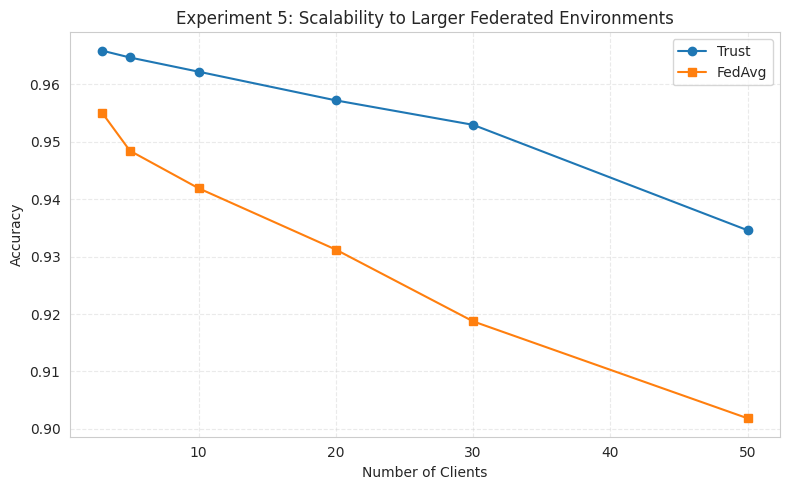

In [26]:
# ============================================================
# EXPERIMENT 5: LARGER CLIENT SCALABILITY
# ============================================================
print("\n" + "="*80)
print("EXPERIMENT 5: Larger client scalability")
print("="*80)

scal_rows = []
scal_results = {}

for n_clients in exp_config["scalability_clients"]:
    res = exp_run_cv_experiment(
        cfg=exp_config["drift_cfg"]["SEVERE DRIFT"],
        num_clients=n_clients,
        folds=exp_config["scalability_folds"],
        seed=exp_config["random_state"],
        light=True,
        trust_mode=exp_config["trust_ablation_modes"]["Accuracy + Confidence + Historical Trust"],
        methods=["Trust", "FedAvg"],
        scenario_name=f"SCALE_{n_clients}"
    )
    scal_results[n_clients] = res
    scal_rows.append({
        "Clients": n_clients,
        "Trust Accuracy": res["Trust"]["mean_acc"],
        "FedAvg Accuracy": res["FedAvg"]["mean_acc"],
        "Trust Macro F1": res["Trust"]["mean_macro_f1"],
        "FedAvg Macro F1": res["FedAvg"]["mean_macro_f1"]
    })

scal_df = pd.DataFrame(scal_rows)
display(scal_df)
scal_df.to_csv("exp5_scalability_3_to_50.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(scal_df["Clients"], scal_df["Trust Accuracy"], marker="o", label="Trust")
plt.plot(scal_df["Clients"], scal_df["FedAvg Accuracy"], marker="s", label="FedAvg")
plt.xlabel("Number of Clients")
plt.ylabel("Accuracy")
plt.title("Experiment 5: Scalability to Larger Federated Environments")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig("exp5_scalability.png", dpi=300)
plt.show()


In [27]:
# ============================================================
# EXPERIMENT 6: INDEPENDENT RUNS
# ============================================================
print("\n" + "="*80)
print("EXPERIMENT 6: Independent runs")
print("="*80)

ind_rows = []
run_means = []

for run in range(exp_config["independent_runs"]):
    seed = exp_config["random_state"] + 100 * run
    res = exp_run_cv_experiment(
        cfg=exp_config["drift_cfg"]["SEVERE DRIFT"],
        num_clients=exp_config["base_clients"],
        folds=exp_config["cv_folds"],
        seed=seed,
        light=True,
        trust_mode=exp_config["trust_ablation_modes"]["Accuracy + Confidence + Historical Trust"],
        methods=["Trust"],
        scenario_name=f"RUN_{run+1}"
    )
    acc = res["Trust"]["mean_acc"]
    run_means.append(acc)
    ind_rows.append({
        "Run": run + 1,
        "Accuracy": acc,
        "Macro F1": res["Trust"]["mean_macro_f1"]
    })

ind_df = pd.DataFrame(ind_rows)
display(ind_df)
ind_df.to_csv("exp6_independent_runs.csv", index=False)

mean_acc = float(np.mean(run_means))
std_acc = float(np.std(run_means, ddof=1)) if len(run_means) > 1 else 0.0
print(f"\nIndependent Runs: Mean Accuracy = {mean_acc:.4f}, Std = {std_acc:.4f}")




EXPERIMENT 6: Independent runs
[RUN_1] Fold 1/5 done.
[RUN_1] Fold 2/5 done.
[RUN_1] Fold 3/5 done.
[RUN_1] Fold 4/5 done.
[RUN_1] Fold 5/5 done.
[RUN_2] Fold 1/5 done.
[RUN_2] Fold 2/5 done.
[RUN_2] Fold 3/5 done.
[RUN_2] Fold 4/5 done.
[RUN_2] Fold 5/5 done.
[RUN_3] Fold 1/5 done.
[RUN_3] Fold 2/5 done.
[RUN_3] Fold 3/5 done.
[RUN_3] Fold 4/5 done.
[RUN_3] Fold 5/5 done.
[RUN_4] Fold 1/5 done.
[RUN_4] Fold 2/5 done.
[RUN_4] Fold 3/5 done.
[RUN_4] Fold 4/5 done.
[RUN_4] Fold 5/5 done.
[RUN_5] Fold 1/5 done.
[RUN_5] Fold 2/5 done.
[RUN_5] Fold 3/5 done.
[RUN_5] Fold 4/5 done.
[RUN_5] Fold 5/5 done.


,Run,Accuracy,Macro F1
0,1,0.96470,0.964455
1,2,0.96485,0.964609
2,3,0.96493,0.964685
3,4,0.96459,0.964337
4,5,0.96457,0.964303



Independent Runs: Mean Accuracy = 0.9647, Std = 0.0002


In [28]:
# ============================================================
# EXPERIMENT 7: DATASET HARMONIZATION VALIDATION
# ============================================================
print("\n" + "="*80)
print("EXPERIMENT 7: Dataset harmonization validation")
print("="*80)

# ------------------------------------------------------------
# Feature counts
# ------------------------------------------------------------
final_training_features = X_sc.shape[1] if "X_sc" in globals() else 118

harm_rows = [
    {
        "Dataset": "NSL-KDD",
        "Original Features": 44,
        "Final Training Features": final_training_features
    },
    {
        "Dataset": "CICIDS2017",
        "Original Features": 79,
        "Final Training Features": final_training_features
    },
    {
        "Dataset": "ToN-IoT",
        "Original Features": 21,
        "Final Training Features": final_training_features
    }
]

harm_feat_df = pd.DataFrame(harm_rows)

print("\nFeature Harmonization Summary")
display(harm_feat_df)

harm_feat_df.to_csv(
    "exp7_feature_harmonization.csv",
    index=False
)

# ------------------------------------------------------------
# Sample counts
# ------------------------------------------------------------
sample_rows = []

for ds_name, var_name in [
    ("NSL-KDD", "clean_nsl"),
    ("CICIDS2017", "clean_cic"),
    ("ToN-IoT", "clean_ton")
]:
    if var_name in globals():
        n_samples = int(globals()[var_name].shape[0])
    elif "df" in globals():
        n_samples = int(len(df))
    else:
        n_samples = int(len(y_enc))

    sample_rows.append({
        "Dataset": ds_name,
        "Samples Used": n_samples
    })

harm_sample_df = pd.DataFrame(sample_rows)

print("\nSample Counts")
display(harm_sample_df)

harm_sample_df.to_csv(
    "exp7_sample_counts.csv",
    index=False
)



EXPERIMENT 7: Dataset harmonization validation

Feature Harmonization Summary


,Dataset,Original Features,Final Training Features
0,NSL-KDD,44,118
1,CICIDS2017,79,118
2,ToN-IoT,21,118



Sample Counts


,Dataset,Samples Used
0,NSL-KDD,125937
1,CICIDS2017,471902
2,ToN-IoT,261119


In [21]:
X_temp = df.drop(columns=["label"])

print("="*60)
print("FEATURE DIAGNOSTIC")
print("="*60)

print("Total features before removal:", X_temp.shape[1])

constant_cols = X_temp.columns[X_temp.nunique() <= 1]

print("Constant features:", len(constant_cols))
print("Features after removal:", X_temp.shape[1] - len(constant_cols))

print("\nConstant feature names:")
for c in constant_cols:
    print(c)

print("\nVerification:")
print("130 -", len(constant_cols), "=", X_temp.shape[1] - len(constant_cols))

FEATURE DIAGNOSTIC
Total features before removal: 130
Constant features: 12
Features after removal: 118

Constant feature names:
19
20
Bwd Avg Bulk Rate
Bwd Avg Bytes/Bulk
Bwd Avg Packets/Bulk
Bwd PSH Flags
Bwd URG Flags
CWE Flag Count
Fwd Avg Bulk Rate
Fwd Avg Bytes/Bulk
Fwd Avg Packets/Bulk
Fwd URG Flags

Verification:
130 - 12 = 118



EXPERIMENT 8: Confidence interval analysis


,Scenario,Trust Mean,Trust 95% CI Half-Width,FedAvg Mean,FedAvg 95% CI Half-Width
0,NO DRIFT,0.96385,0.002651,0.96034,0.001240
1,MILD DRIFT,0.96470,0.001409,0.95015,0.001742
2,SEVERE DRIFT,0.96470,0.001409,0.94431,0.002265


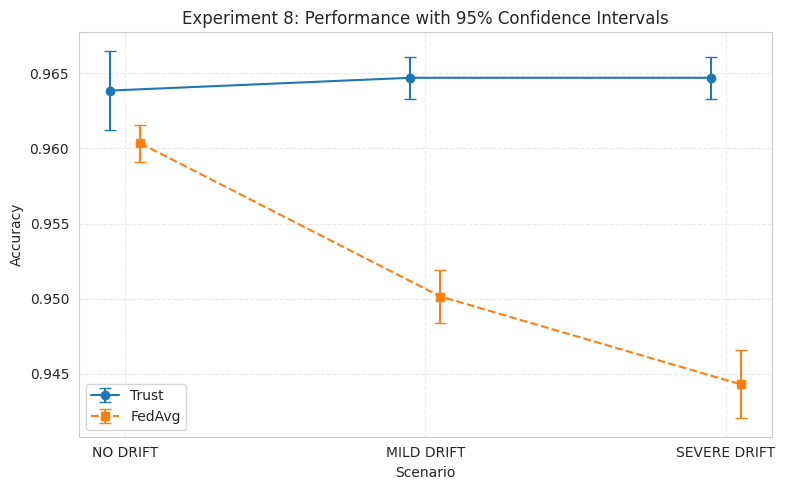

In [29]:
# ============================================================
# EXPERIMENT 8: CONFIDENCE INTERVAL ANALYSIS
# ============================================================
print("\n" + "="*80)
print("EXPERIMENT 8: Confidence interval analysis")
print("="*80)

def exp_mean_ci(data, confidence=0.95):
    data = np.asarray(data, dtype=float)
    mean = np.mean(data)
    sem = np.std(data, ddof=1) / np.sqrt(len(data))
    h = sem * t.ppf((1 + confidence) / 2., len(data) - 1)
    return mean, h

ci_rows = []
for scenario in exp_config["robust_scenarios"]:
    trust_accs = robust_results[scenario]["Trust"]["fold_accs"]
    fed_accs = robust_results[scenario]["FedAvg"]["fold_accs"]

    tm, th = exp_mean_ci(trust_accs)
    fm, fh = exp_mean_ci(fed_accs)

    ci_rows.append({
        "Scenario": scenario,
        "Trust Mean": tm,
        "Trust 95% CI Half-Width": th,
        "FedAvg Mean": fm,
        "FedAvg 95% CI Half-Width": fh
    })

ci_df = pd.DataFrame(ci_rows)
display(ci_df)
ci_df.to_csv("exp8_confidence_intervals.csv", index=False)

x = np.arange(len(ci_df))
plt.figure(figsize=(8, 5))
plt.errorbar(x - 0.05, ci_df["Trust Mean"], yerr=ci_df["Trust 95% CI Half-Width"],
             fmt="o-", capsize=4, label="Trust")
plt.errorbar(x + 0.05, ci_df["FedAvg Mean"], yerr=ci_df["FedAvg 95% CI Half-Width"],
             fmt="s--", capsize=4, label="FedAvg")
plt.xticks(x, ci_df["Scenario"])
plt.xlabel("Scenario")
plt.ylabel("Accuracy")
plt.title("Experiment 8: Performance with 95% Confidence Intervals")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig("exp8_ci_plot.png", dpi=300)
plt.show()




EXPERIMENT 9: Trust component ablation
[ABL_Accuracy Only] Fold 1/5 done.
[ABL_Accuracy Only] Fold 2/5 done.
[ABL_Accuracy Only] Fold 3/5 done.
[ABL_Accuracy Only] Fold 4/5 done.
[ABL_Accuracy Only] Fold 5/5 done.
[ABL_Accuracy + Confidence] Fold 1/5 done.
[ABL_Accuracy + Confidence] Fold 2/5 done.
[ABL_Accuracy + Confidence] Fold 3/5 done.
[ABL_Accuracy + Confidence] Fold 4/5 done.
[ABL_Accuracy + Confidence] Fold 5/5 done.
[ABL_Accuracy + Confidence + Historical Trust] Fold 1/5 done.
[ABL_Accuracy + Confidence + Historical Trust] Fold 2/5 done.
[ABL_Accuracy + Confidence + Historical Trust] Fold 3/5 done.
[ABL_Accuracy + Confidence + Historical Trust] Fold 4/5 done.
[ABL_Accuracy + Confidence + Historical Trust] Fold 5/5 done.


,Trust Formula,Trust Accuracy,Trust Macro F1,FedAvg Accuracy
0,Accuracy Only,0.96478,0.964535,0.94431
1,Accuracy + Confidence,0.96470,0.964455,0.94431
2,Accuracy + Confidence + Historical Trust,0.96470,0.964455,0.94431


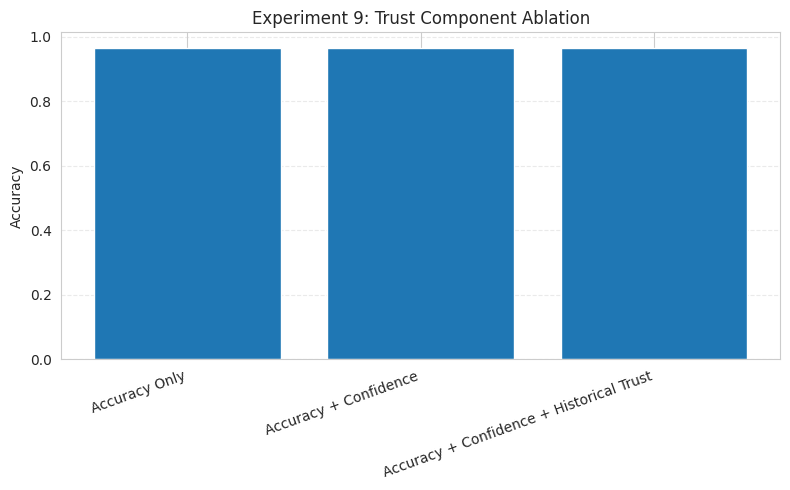


OPTIONAL: Statistical significance check
NO DRIFT: paired t-test p-value = 0.022613 (p < 0.05 => significant)
MILD DRIFT: paired t-test p-value = 0.000003 (p < 0.05 => significant)
SEVERE DRIFT: paired t-test p-value = 0.000004 (p < 0.05 => significant)

FINAL SUMMARY


,Scenario,Trust Acc,FedAvg Acc,Trust Macro F1,FedAvg Macro F1
0,NO DRIFT,0.96385,0.96034,0.963578,0.959978
1,MILD DRIFT,0.96470,0.95015,0.964455,0.949640
2,SEVERE DRIFT,0.96470,0.94431,0.964455,0.943795



All missing experiments finished.
Saved files:
 - exp1_robust_baselines.csv
 - exp2_poisoning_attack.csv
 - exp3_communication_overhead.csv
 - exp4_audit_log_growth.csv
 - exp5_scalability_3_to_50.csv
 - exp6_independent_runs.csv
 - exp7_feature_harmonization.csv
 - exp7_sample_counts.csv
 - exp8_confidence_intervals.csv
 - exp9_trust_ablation.csv
 - final_summary_trust_vs_fedavg.csv


In [30]:
# ============================================================
# EXPERIMENT 9: TRUST COMPONENT ABLATION
# ============================================================
print("\n" + "="*80)
print("EXPERIMENT 9: Trust component ablation")
print("="*80)

ablation_rows = []
ablation_results = {}

for mode_name, (alpha, beta, gamma) in exp_config["trust_ablation_modes"].items():
    res = exp_run_cv_experiment(
        cfg=exp_config["drift_cfg"]["SEVERE DRIFT"],
        num_clients=exp_config["base_clients"],
        folds=exp_config["cv_folds"],
        seed=exp_config["random_state"],
        light=True,
        trust_mode=(alpha, beta, gamma),
        methods=["Trust", "FedAvg"],
        scenario_name=f"ABL_{mode_name}"
    )
    ablation_results[mode_name] = res
    ablation_rows.append({
        "Trust Formula": mode_name,
        "Trust Accuracy": res["Trust"]["mean_acc"],
        "Trust Macro F1": res["Trust"]["mean_macro_f1"],
        "FedAvg Accuracy": res["FedAvg"]["mean_acc"]
    })

ablation_df = pd.DataFrame(ablation_rows)
display(ablation_df)
ablation_df.to_csv("exp9_trust_ablation.csv", index=False)

plt.figure(figsize=(8, 5))
plt.bar(ablation_df["Trust Formula"], ablation_df["Trust Accuracy"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Accuracy")
plt.title("Experiment 9: Trust Component Ablation")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("exp9_trust_ablation.png", dpi=300)
plt.show()

# ============================================================
# OPTIONAL: STATISTICAL SIGNIFICANCE CHECK (Trust vs FedAvg)
# ============================================================
print("\n" + "="*80)
print("OPTIONAL: Statistical significance check")
print("="*80)

for scenario in exp_config["robust_scenarios"]:
    trust_accs = np.array(robust_results[scenario]["Trust"]["fold_accs"])
    fed_accs = np.array(robust_results[scenario]["FedAvg"]["fold_accs"])
    if len(trust_accs) == len(fed_accs) and len(trust_accs) > 1:
        # paired t-test
        diff = trust_accs - fed_accs
        mean_diff = diff.mean()
        sd = diff.std(ddof=1)
        sem = sd / np.sqrt(len(diff))
        t_stat = mean_diff / (sem + 1e-12)
        p_val = 2 * (1 - t.cdf(abs(t_stat), df=len(diff)-1))
        print(f"{scenario}: paired t-test p-value = {p_val:.6f} (p < 0.05 => significant)")
    else:
        print(f"{scenario}: insufficient data for paired t-test")

# ============================================================
# FINAL SUMMARY TABLES
# ============================================================
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

summary_rows = []
for scenario in exp_config["robust_scenarios"]:
    summary_rows.append({
        "Scenario": scenario,
        "Trust Acc": robust_results[scenario]["Trust"]["mean_acc"],
        "FedAvg Acc": robust_results[scenario]["FedAvg"]["mean_acc"],
        "Trust Macro F1": robust_results[scenario]["Trust"]["mean_macro_f1"],
        "FedAvg Macro F1": robust_results[scenario]["FedAvg"]["mean_macro_f1"],
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_df.to_csv("final_summary_trust_vs_fedavg.csv", index=False)

print("\nAll missing experiments finished.")
print("Saved files:")
for f in [
    "exp1_robust_baselines.csv",
    "exp2_poisoning_attack.csv",
    "exp3_communication_overhead.csv",
    "exp4_audit_log_growth.csv",
    "exp5_scalability_3_to_50.csv",
    "exp6_independent_runs.csv",
    "exp7_feature_harmonization.csv",
    "exp7_sample_counts.csv",
    "exp8_confidence_intervals.csv",
    "exp9_trust_ablation.csv",
    "final_summary_trust_vs_fedavg.csv",
]:
    print(" -", f)